EKSTRAKSI DATASET CIFAR-10
📍 Base Path: C:/Users/Ahsan/Downloads/data/archive

1. MENGUNDUH DATASET CIFAR-10
✅ File CIFAR-10 sudah ada: C:/Users/Ahsan/Downloads/data/archive\cifar-10-python.tar.gz

2. MENGEKSTRAK FILE CIFAR-10
✅ File CIFAR-10 sudah diekstrak: C:/Users/Ahsan/Downloads/data/archive\cifar-10-batches-py

3. MEMBUAT STRUKTUR FOLDER
📁 Membuat folder: C:/Users/Ahsan/Downloads/data/archive\cifar10_train\airplane
📁 Membuat folder: C:/Users/Ahsan/Downloads/data/archive\cifar10_test\airplane
📁 Membuat folder: C:/Users/Ahsan/Downloads/data/archive\cifar10_train\automobile
📁 Membuat folder: C:/Users/Ahsan/Downloads/data/archive\cifar10_test\automobile
📁 Membuat folder: C:/Users/Ahsan/Downloads/data/archive\cifar10_train\bird
📁 Membuat folder: C:/Users/Ahsan/Downloads/data/archive\cifar10_test\bird
📁 Membuat folder: C:/Users/Ahsan/Downloads/data/archive\cifar10_train\cat
📁 Membuat folder: C:/Users/Ahsan/Downloads/data/archive\cifar10_test\cat
📁 Membuat folder: C:/Users/Ahsan/Downloa

Processing training: 100%|██████████| 50000/50000 [00:23<00:00, 2124.21it/s]


✅ Berhasil menyimpan 50000 gambar training

6. MENYIMPAN GAMBAR TEST
💾 Menyimpan gambar test...


Processing test: 100%|██████████| 10000/10000 [00:04<00:00, 2178.18it/s]


✅ Berhasil menyimpan 10000 gambar test

7. VERIFIKASI HASIL EKSTRAKSI

🔍 Memverifikasi ekstraksi...
  airplane     - Train:  5000, Test:  1000
  automobile   - Train:  5000, Test:  1000
  bird         - Train:  5000, Test:  1000
  cat          - Train:  5000, Test:  1000
  deer         - Train:  5000, Test:  1000
  dog          - Train:  5000, Test:  1000
  frog         - Train:  5000, Test:  1000
  horse        - Train:  5000, Test:  1000
  ship         - Train:  5000, Test:  1000
  truck        - Train:  5000, Test:  1000
📊 TOTAL - Train: 50000, Test: 10000
✅ Ekstraksi berhasil dan lengkap!

🎉 EKSTRAKSI CIFAR-10 BERHASIL!
📁 Folder Training: C:/Users/Ahsan/Downloads/data/archive\cifar10_train
📁 Folder Test: C:/Users/Ahsan/Downloads/data/archive\cifar10_test
📊 Total: 50,000 gambar training + 10,000 gambar test

📊 INFORMASI DATASET CIFAR-10

KELAS - JUMLAH GAMBAR (Training / Test):
--------------------------------------------------
  airplane     :  5000 /  1000
  automobile   :  5000 /

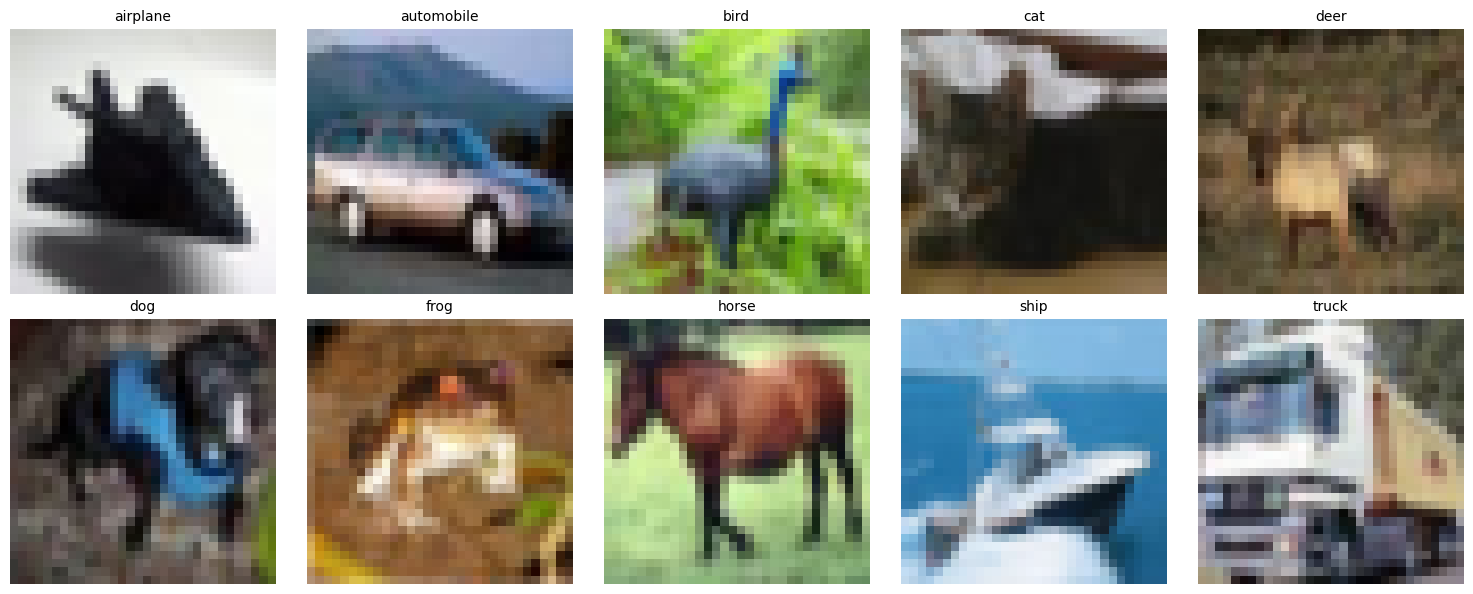

✅ File konfigurasi disimpan di: C:/Users/Ahsan/Downloads/data/archive\cifar10_config.py

📋 Konfigurasi untuk kode analisis:

# =============================================
# KONFIGURASI - CIFAR-10 DATASET (UPDATED PATH)
# =============================================
base_path = "C:/Users/Ahsan/Downloads/data/archive"
cifar10_train_folder = "C:/Users/Ahsan/Downloads/data/archive\cifar10_train"
cifar10_test_folder = "C:/Users/Ahsan/Downloads/data/archive\cifar10_test"

# 10 kelas CIFAR-10
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# File output dengan path yang sesuai
output_excel = "C:/Users/Ahsan/Downloads/data/archive\cifar10_data_ekstraksi_rgb_10kelas.xlsx"
ecdf_output_csv = "C:/Users/Ahsan/Downloads/data/archive\cifar10_data_ecdf_rgb_10kelas.csv"
ecdf_intensity_output_excel = "C:/Users/Ahsan/Downloads/data/archive\cifar10_data_ecdf_intensitas_10kelas.xlsx"
conversion_output_excel = "C:/Users/Ahsan/Downloads/data/ar

In [1]:
import os
import pickle
import numpy as np
import cv2
from tqdm import tqdm
import tarfile
import urllib.request

# =============================================
# KONFIGURASI CIFAR-10 - PATH DIESKSPOR KE DOWNLOADS/ARCHIVE
# =============================================
base_path = "C:/Users/Ahsan/Downloads/data/archive"
cifar10_url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
cifar10_tar_path = os.path.join(base_path, "cifar-10-python.tar.gz")
cifar10_extract_path = os.path.join(base_path, "cifar-10-batches-py")  # DIUBAH: folder yang benar
output_train_folder = os.path.join(base_path, "cifar10_train")
output_test_folder = os.path.join(base_path, "cifar10_test")

# 10 kelas CIFAR-10
cifar10_classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# =============================================
# FUNGSI UNTUK MENGUNDUH CIFAR-10
# =============================================

def download_cifar10():
    """
    Mengunduh dataset CIFAR-10 jika belum ada
    """
    # Buat folder base path jika belum ada
    os.makedirs(base_path, exist_ok=True)
    
    if os.path.exists(cifar10_tar_path):
        print(f"✅ File CIFAR-10 sudah ada: {cifar10_tar_path}")
        return True
    
    print("📥 Mengunduh CIFAR-10 dataset...")
    try:
        urllib.request.urlretrieve(cifar10_url, cifar10_tar_path)
        print(f"✅ Berhasil mengunduh: {cifar10_tar_path}")
        return True
    except Exception as e:
        print(f"❌ Gagal mengunduh CIFAR-10: {e}")
        return False

def extract_cifar10():
    """
    Mengekstrak file tar.gz CIFAR-10
    """
    if os.path.exists(cifar10_extract_path):
        print(f"✅ File CIFAR-10 sudah diekstrak: {cifar10_extract_path}")
        return True
    
    if not os.path.exists(cifar10_tar_path):
        print("❌ File CIFAR-10 tidak ditemukan. Silakan unduh terlebih dahulu.")
        return False
    
    print("📦 Mengekstrak CIFAR-10...")
    try:
        with tarfile.open(cifar10_tar_path, 'r:gz') as tar:
            tar.extractall(base_path)
        print(f"✅ Berhasil mengekstrak ke: {cifar10_extract_path}")
        return True
    except Exception as e:
        print(f"❌ Gagal mengekstrak CIFAR-10: {e}")
        return False

# =============================================
# FUNGSI UNTUK MEMBACA FILE BATCH CIFAR-10
# =============================================

def unpickle(file):
    """
    Membaca file batch CIFAR-10
    """
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

def load_cifar10_data():
    """
    Memuat semua data CIFAR-10 dari file batch
    """
    data_path = cifar10_extract_path
    
    # Periksa apakah folder ada
    if not os.path.exists(data_path):
        print(f"❌ Folder tidak ditemukan: {data_path}")
        # Coba cari folder alternatif
        possible_paths = [
            os.path.join(base_path, "cifar-10-batches-py"),
            os.path.join(base_path, "cifar-10-python"),
            os.path.join(base_path, "cifar10")
        ]
        
        for path in possible_paths:
            if os.path.exists(path):
                data_path = path
                print(f"✅ Menggunakan folder alternatif: {data_path}")
                break
        else:
            print("❌ Tidak ada folder CIFAR-10 yang ditemukan!")
            return None, None, None, None
    
    # Data training (5 batch)
    train_data = []
    train_labels = []
    
    for i in range(1, 6):
        batch_file = os.path.join(data_path, f'data_batch_{i}')
        print(f"📖 Membaca: {batch_file}")
        
        if not os.path.exists(batch_file):
            print(f"❌ File batch tidak ditemukan: {batch_file}")
            # Coba dengan ekstensi berbeda
            batch_file_alt = os.path.join(data_path, f'data_batch_{i}')
            if not os.path.exists(batch_file_alt):
                print(f"❌ File batch alternatif juga tidak ditemukan: {batch_file_alt}")
                continue
        
        try:
            batch_dict = unpickle(batch_file)
            batch_data = batch_dict[b'data']
            batch_labels = batch_dict[b'labels']
            
            train_data.append(batch_data)
            train_labels.extend(batch_labels)
            print(f"✅ Berhasil membaca data_batch_{i}")
        except Exception as e:
            print(f"❌ Gagal membaca data_batch_{i}: {e}")
            return None, None, None, None
    
    if not train_data:
        print("❌ Tidak ada data training yang berhasil dibaca!")
        return None, None, None, None
    
    # Gabungkan semua data training
    train_data = np.vstack(train_data)
    train_labels = np.array(train_labels)
    
    # Data test
    test_batch_file = os.path.join(data_path, 'test_batch')
    print(f"📖 Membaca: {test_batch_file}")
    
    if not os.path.exists(test_batch_file):
        print(f"❌ File test batch tidak ditemukan: {test_batch_file}")
        return None, None, None, None
    
    try:
        test_dict = unpickle(test_batch_file)
        test_data = test_dict[b'data']
        test_labels = test_dict[b'labels']
        test_labels = np.array(test_labels)
        
        print(f"✅ Berhasil membaca test_batch")
    except Exception as e:
        print(f"❌ Gagal membaca test_batch: {e}")
        return None, None, None, None
    
    print(f"📊 Data Training: {train_data.shape}, Labels: {train_labels.shape}")
    print(f"📊 Data Test: {test_data.shape}, Labels: {test_labels.shape}")
    
    return train_data, train_labels, test_data, test_labels

# =============================================
# FUNGSI KONVERSI DAN PENYIMPANAN GAMBAR
# =============================================

def create_folders():
    """
    Membuat folder untuk setiap kelas dalam train dan test
    """
    # Buat folder utama
    os.makedirs(output_train_folder, exist_ok=True)
    os.makedirs(output_test_folder, exist_ok=True)
    
    # Buat subfolder untuk setiap kelas
    for class_name in cifar10_classes:
        train_class_path = os.path.join(output_train_folder, class_name)
        test_class_path = os.path.join(output_test_folder, class_name)
        
        os.makedirs(train_class_path, exist_ok=True)
        os.makedirs(test_class_path, exist_ok=True)
        
        print(f"📁 Membuat folder: {train_class_path}")
        print(f"📁 Membuat folder: {test_class_path}")

def convert_and_save_images(data, labels, output_folder, dataset_type="train"):
    """
    Mengkonversi data CIFAR-10 ke gambar dan menyimpannya
    """
    if data is None or labels is None:
        print(f"❌ Data {dataset_type} tidak valid!")
        return
    
    # Konversi bentuk data: (n, 3072) -> (n, 32, 32, 3)
    # CIFAR-10 format: 3072 = 3*32*32 (R, G, B channels)
    try:
        images = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    except Exception as e:
        print(f"❌ Gagal reshape data {dataset_type}: {e}")
        return
    
    print(f"💾 Menyimpan gambar {dataset_type}...")
    
    for i in tqdm(range(len(images)), desc=f"Processing {dataset_type}"):
        # Dapatkan gambar dan label
        img = images[i]
        label_idx = labels[i]
        class_name = cifar10_classes[label_idx]
        
        # Konversi dari RGB ke BGR untuk OpenCV
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        
        # Nama file: class_index.png
        filename = f"{class_name}_{i:05d}.png"
        filepath = os.path.join(output_folder, class_name, filename)
        
        # Simpan gambar
        success = cv2.imwrite(filepath, img_bgr)
        if not success:
            print(f"❌ Gagal menyimpan: {filepath}")
    
    print(f"✅ Berhasil menyimpan {len(images)} gambar {dataset_type}")

def verify_extraction():
    """
    Memverifikasi bahwa ekstraksi berhasil
    """
    print("\n🔍 Memverifikasi ekstraksi...")
    
    total_train = 0
    total_test = 0
    
    for class_name in cifar10_classes:
        train_class_path = os.path.join(output_train_folder, class_name)
        test_class_path = os.path.join(output_test_folder, class_name)
        
        train_count = len([f for f in os.listdir(train_class_path) if f.endswith('.png')]) if os.path.exists(train_class_path) else 0
        test_count = len([f for f in os.listdir(test_class_path) if f.endswith('.png')]) if os.path.exists(test_class_path) else 0
        
        total_train += train_count
        total_test += test_count
        
        print(f"  {class_name:12s} - Train: {train_count:5d}, Test: {test_count:5d}")
    
    print(f"📊 TOTAL - Train: {total_train}, Test: {total_test}")
    
    expected_train = 50000
    expected_test = 10000
    
    if total_train == expected_train and total_test == expected_test:
        print("✅ Ekstraksi berhasil dan lengkap!")
        return True
    else:
        print(f"⚠️  Jumlah gambar tidak sesuai! Diharapkan Train: {expected_train}, Test: {expected_test}")
        print(f"   Mungkin ada masalah dengan ekstraksi, tetapi proses akan dilanjutkan.")
        return True  # Tetap return True untuk melanjutkan

# =============================================
# FUNGSI UTAMA
# =============================================

def main_extract_cifar10():
    """
    Fungsi utama untuk mengekstrak dataset CIFAR-10
    """
    print("=" * 70)
    print("EKSTRAKSI DATASET CIFAR-10")
    print("=" * 70)
    print(f"📍 Base Path: {base_path}")
    
    # Langkah 1: Unduh dataset jika belum ada
    print("\n1. MENGUNDUH DATASET CIFAR-10")
    if not download_cifar10():
        return False
    
    # Langkah 2: Ekstrak file tar.gz
    print("\n2. MENGEKSTRAK FILE CIFAR-10")
    if not extract_cifar10():
        return False
    
    # Langkah 3: Buat folder struktur
    print("\n3. MEMBUAT STRUKTUR FOLDER")
    create_folders()
    
    # Langkah 4: Muat data CIFAR-10
    print("\n4. MEMUAT DATA CIFAR-10")
    train_data, train_labels, test_data, test_labels = load_cifar10_data()
    
    if train_data is None:
        print("❌ Gagal memuat data CIFAR-10!")
        return False
    
    # Langkah 5: Konversi dan simpan gambar training
    print("\n5. MENYIMPAN GAMBAR TRAINING")
    convert_and_save_images(train_data, train_labels, output_train_folder, "training")
    
    # Langkah 6: Konversi dan simpan gambar test
    print("\n6. MENYIMPAN GAMBAR TEST")
    convert_and_save_images(test_data, test_labels, output_test_folder, "test")
    
    # Langkah 7: Verifikasi hasil
    print("\n7. VERIFIKASI HASIL EKSTRAKSI")
    success = verify_extraction()
    
    if success:
        print("\n🎉 EKSTRAKSI CIFAR-10 BERHASIL!")
        print(f"📁 Folder Training: {output_train_folder}")
        print(f"📁 Folder Test: {output_test_folder}")
        print(f"📊 Total: 50,000 gambar training + 10,000 gambar test")
    else:
        print("\n❌ EKSTRAKSI CIFAR-10 GAGAL!")
    
    return success

def cleanup_temp_files():
    """
    Membersihkan file temporary (opsional)
    """
    print("\n🧹 Membersihkan file temporary...")
    
    if os.path.exists(cifar10_tar_path):
        os.remove(cifar10_tar_path)
        print(f"✅ Menghapus: {cifar10_tar_path}")
    
    # Hapus folder ekstraksi sementara
    extract_folders = [
        os.path.join(base_path, "cifar-10-batches-py"),
        os.path.join(base_path, "cifar-10-python"),
        os.path.join(base_path, "cifar10")
    ]
    
    for folder in extract_folders:
        if os.path.exists(folder):
            import shutil
            shutil.rmtree(folder)
            print(f"✅ Menghapus: {folder}")

# =============================================
# FUNGSI TAMBAHAN: MEMUAT DATA LANGSUNG DARI FOLDER
# =============================================

def load_images_from_folder(folder_path, img_size=(32, 32)):
    """
    Memuat gambar dari folder yang sudah diekstrak
    """
    images = []
    labels = []
    filenames = []
    
    for class_idx, class_name in enumerate(cifar10_classes):
        class_folder = os.path.join(folder_path, class_name)
        
        if not os.path.exists(class_folder):
            print(f"❌ Folder tidak ditemukan: {class_folder}")
            continue
        
        image_files = [f for f in os.listdir(class_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]
        
        print(f"📁 Memuat {len(image_files)} gambar dari {class_name}...")
        
        for image_file in tqdm(image_files, desc=f"Loading {class_name}"):
            image_path = os.path.join(class_folder, image_file)
            
            # Baca gambar
            img = cv2.imread(image_path)
            if img is not None:
                # Resize jika diperlukan
                if img.shape[:2] != img_size:
                    img = cv2.resize(img, img_size)
                
                # Konversi BGR ke RGB
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                images.append(img_rgb)
                labels.append(class_idx)
                filenames.append(image_file)
    
    return np.array(images), np.array(labels), filenames

def get_dataset_info():
    """
    Menampilkan informasi tentang dataset yang sudah diekstrak
    """
    print("\n📊 INFORMASI DATASET CIFAR-10")
    print("=" * 50)
    
    if not os.path.exists(output_train_folder):
        print("❌ Folder training tidak ditemukan. Jalankan ekstraksi terlebih dahulu.")
        return
    
    total_train = 0
    total_test = 0
    
    print("\nKELAS - JUMLAH GAMBAR (Training / Test):")
    print("-" * 50)
    
    for class_name in cifar10_classes:
        train_path = os.path.join(output_train_folder, class_name)
        test_path = os.path.join(output_test_folder, class_name)
        
        train_count = len([f for f in os.listdir(train_path) if f.endswith('.png')]) if os.path.exists(train_path) else 0
        test_count = len([f for f in os.listdir(test_path) if f.endswith('.png')]) if os.path.exists(test_path) else 0
        
        total_train += train_count
        total_test += test_count
        
        print(f"  {class_name:12s} : {train_count:5d} / {test_count:5d}")
    
    print("-" * 50)
    print(f"  TOTAL        : {total_train:5d} / {total_test:5d}")
    print(f"  GRAND TOTAL  : {total_train + total_test:5d}")
    
    # Tampilkan contoh gambar dari setiap kelas
    print("\n🖼️  CONTOH GAMBAR:")
    display_sample_images()

def display_sample_images(samples_per_class=2):
    """
    Menampilkan contoh gambar dari setiap kelas
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()
    
    for class_idx, class_name in enumerate(cifar10_classes):
        class_folder = os.path.join(output_train_folder, class_name)
        
        if not os.path.exists(class_folder):
            continue
            
        image_files = [f for f in os.listdir(class_folder) if f.endswith('.png')]
        
        if image_files:
            # Ambil sample gambar
            sample_file = image_files[0]
            sample_path = os.path.join(class_folder, sample_file)
            
            # Baca dan tampilkan gambar
            img = cv2.imread(sample_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                axes[class_idx].imshow(img_rgb)
                axes[class_idx].set_title(f'{class_name}', fontsize=10)
                axes[class_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# =============================================
# FUNGSI UNTUK MENGUBAH KONFIGURASI ANALISIS
# =============================================

def update_analysis_config():
    """
    Mengupdate konfigurasi untuk kode analisis
    """
    config_code = f'''
# =============================================
# KONFIGURASI - CIFAR-10 DATASET (UPDATED PATH)
# =============================================
base_path = "{base_path}"
cifar10_train_folder = "{output_train_folder}"
cifar10_test_folder = "{output_test_folder}"

# 10 kelas CIFAR-10
cifar10_classes = {cifar10_classes}

# File output dengan path yang sesuai
output_excel = "{os.path.join(base_path, "cifar10_data_ekstraksi_rgb_10kelas.xlsx")}"
ecdf_output_csv = "{os.path.join(base_path, "cifar10_data_ecdf_rgb_10kelas.csv")}"
ecdf_intensity_output_excel = "{os.path.join(base_path, "cifar10_data_ecdf_intensitas_10kelas.xlsx")}"
conversion_output_excel = "{os.path.join(base_path, "cifar10_data_ecdf_cdf_konversi_10kelas.xlsx")}"
clustering_output_excel = "{os.path.join(base_path, "cifar10_hasil_clustering_10kelas.xlsx")}"
centroid_output_file = "{os.path.join(base_path, "cifar10_centroid_10kelas.pkl")}"

p = 32  # Ukuran resize gambar: p x p (sesuai CIFAR-10 asli)
'''

    config_file_path = os.path.join(base_path, "cifar10_config.py")
    with open(config_file_path, 'w') as f:
        f.write(config_code)
    
    print(f"✅ File konfigurasi disimpan di: {config_file_path}")
    print("\n📋 Konfigurasi untuk kode analisis:")
    print(config_code)

# =============================================
# JALANKAN PROGRAM
# =============================================

if __name__ == "__main__":
    # Pastikan base path ada
    os.makedirs(base_path, exist_ok=True)
    
    # Ekstrak dataset CIFAR-10
    success = main_extract_cifar10()
    
    if success:
        # Tampilkan informasi dataset
        get_dataset_info()
        
        # Buat file konfigurasi untuk kode analisis
        update_analysis_config()
        
        # Opsional: bersihkan file temporary
        cleanup_choice = input("\n🧹 Hapus file temporary (cifar-10-python.tar.gz dan folder ekstraksi)? (y/n): ")
        if cleanup_choice.lower() == 'y':
            cleanup_temp_files()
    
    print("\n✨ Proses selesai!")

PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS INTENSITAS - 10 KELAS CIFAR-10 (TRAINING)

1. PROSES GAMBAR TRAINING DARI 10 KELAS CIFAR-10
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\airplane (label: airplane)
✅ Berhasil memproses 5000 gambar dengan label: airplane
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\automobile (label: automobile)
✅ Berhasil memproses 5000 gambar dengan label: automobile
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\bird (label: bird)
✅ Berhasil memproses 5000 gambar dengan label: bird
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\cat (label: cat)
✅ Berhasil memproses 5000 gambar dengan label: cat
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\deer (label: deer)
✅ Berhasil memproses 5000 gambar dengan label: deer
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train

C:\Users\Ahsan\AppData\Local\Temp\ipykernel_20384\1242079974.py:1063: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)
C:\Users\Ahsan\AppData\Local\Temp\ipykernel_20384\1242079974.py:1063: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)
C:\Users\Ahsan\AppData\Local\Temp\ipykernel_20384\1242079974.py:1063: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)


   ✅ Distribusi intensitas per kelas channel R disimpan: C:/Users/Ahsan/Downloads/data/archive\cifar10_plots_intensitas\distribusi_per_kelas\distribusi_intensitas_per_kelas_R.png


C:\Users\Ahsan\AppData\Local\Temp\ipykernel_20384\1242079974.py:1063: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)
C:\Users\Ahsan\AppData\Local\Temp\ipykernel_20384\1242079974.py:1063: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)
C:\Users\Ahsan\AppData\Local\Temp\ipykernel_20384\1242079974.py:1063: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)


   ✅ Distribusi intensitas per kelas channel G disimpan: C:/Users/Ahsan/Downloads/data/archive\cifar10_plots_intensitas\distribusi_per_kelas\distribusi_intensitas_per_kelas_G.png


C:\Users\Ahsan\AppData\Local\Temp\ipykernel_20384\1242079974.py:1063: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)
C:\Users\Ahsan\AppData\Local\Temp\ipykernel_20384\1242079974.py:1063: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)
C:\Users\Ahsan\AppData\Local\Temp\ipykernel_20384\1242079974.py:1063: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)


   ✅ Distribusi intensitas per kelas channel B disimpan: C:/Users/Ahsan/Downloads/data/archive\cifar10_plots_intensitas\distribusi_per_kelas\distribusi_intensitas_per_kelas_B.png
✅ Semua plot distribusi per kelas disimpan di: C:/Users/Ahsan/Downloads/data/archive\cifar10_plots_intensitas\distribusi_per_kelas

8. MEMBUAT MODEL MATEMATIS V DARI DATA CDF INTENSITAS TRAINING
✅ Model matematis V berhasil dibuat
🔧 Komponen model V: ['R_100', 'R_150', 'R_200', 'G_150', 'G_200', 'B_150', 'B_200']

9. EKSTRAKSI ECDF DARI GAMBAR TRAINING DAN KONVERSI KE CDF MENGGUNAKAN MODEL V

10. MENYIMPAN DATA KONVERSI CDF TRAINING: C:/Users/Ahsan/Downloads/data/archive\cifar10_data_ecdf_cdf_konversi_10kelas.xlsx
💾 Data konversi CDF disimpan ke: C:/Users/Ahsan/Downloads/data/archive\cifar10_data_ecdf_cdf_konversi_10kelas.xlsx

11. PERSIAPAN FITUR UNTUK CLUSTERING DARI CDF HASIL KONVERSI TRAINING

🔍 DEBUG - Label unik di df_features:
label
airplane      5000
automobile    5000
bird          5000
cat           

c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\subprocess.py", line 951, in __init__
 

✅ K-means clustering dengan centroid berhasil!
🔀 Mapping cluster: {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'frog', 5: 'frog', 6: 'frog', 7: 'airplane', 8: 'airplane', 9: 'truck'}

6. ANALISIS HASIL CLUSTERING TESTING

HASIL K-MEANS CLUSTERING - 10 KELAS CIFAR-10

🎯 INFORMASI CENTROID:
   Cluster 0: airplane
   Cluster 1: automobile
   Cluster 2: bird
   Cluster 3: cat
   Cluster 4: frog
   Cluster 5: frog
   Cluster 6: frog
   Cluster 7: airplane
   Cluster 8: airplane
   Cluster 9: truck

📈 AKURASI CLUSTERING: 19.85%
   Benar: 1985/10000

📊 CONFUSION MATRIX:
label_prediksi  airplane  automobile  bird  cat  frog  truck
label_aktual                                                
airplane             551         132    54   50   119     94
automobile           225         271    14  148   136    206
bird                 270         123    90   72   390     55
cat                  270         177    33  133   256    131
deer                 157          97    73   83   54

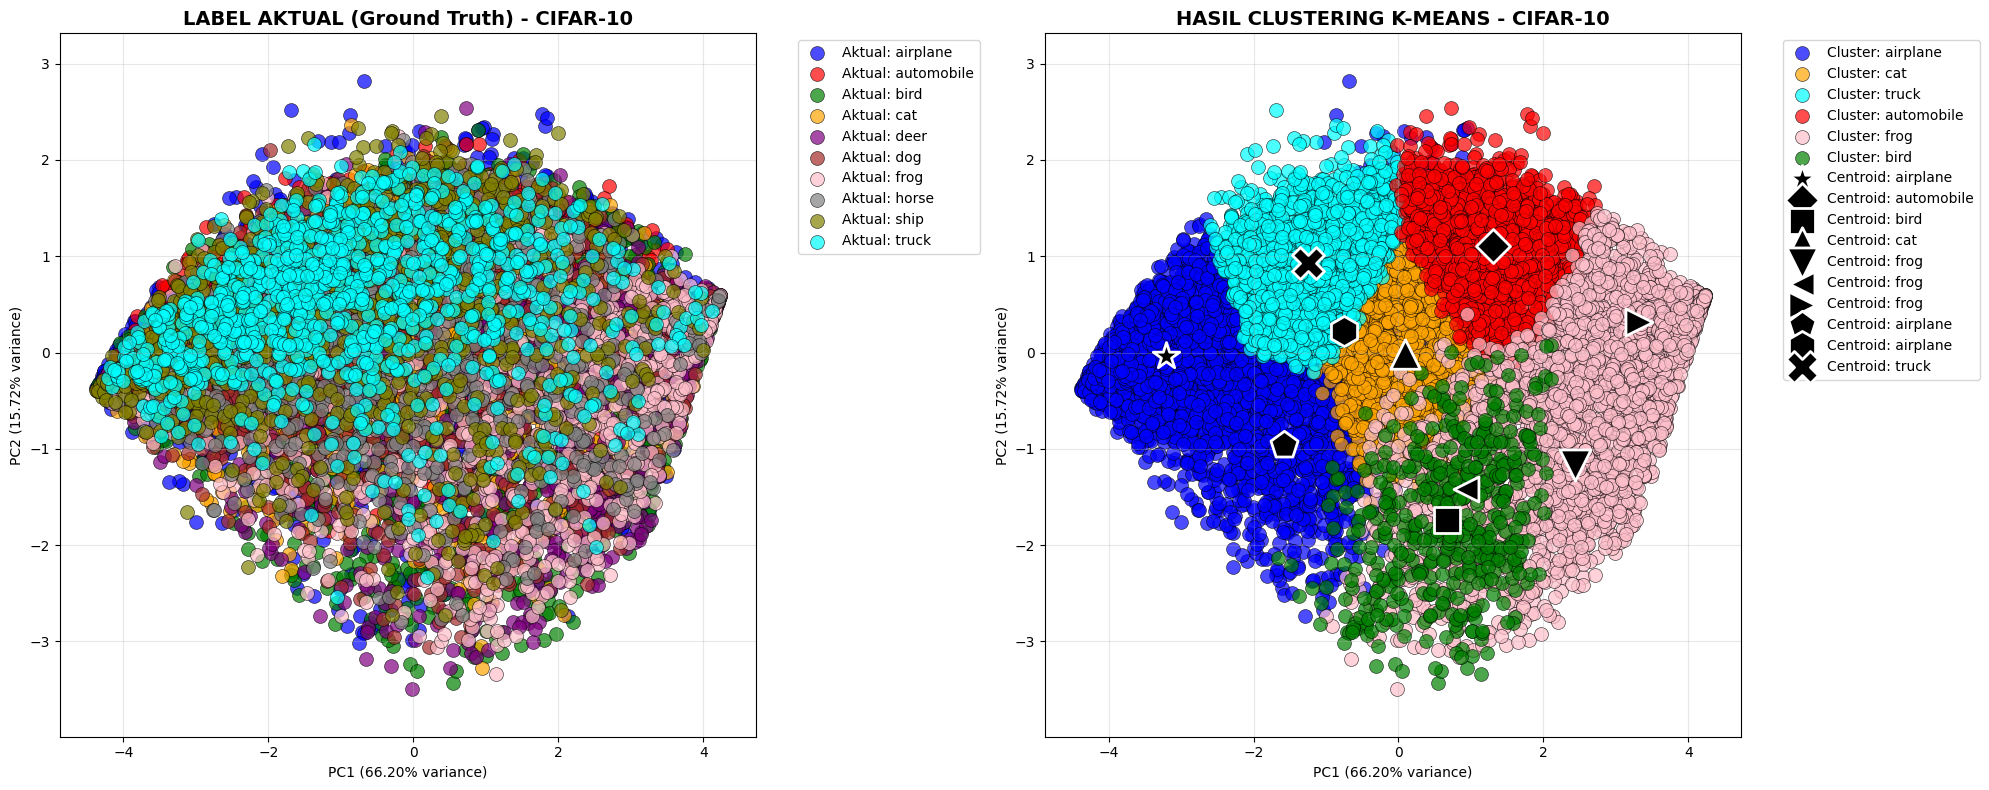


📊 Variance yang dijelaskan oleh PCA:
   PC1: 0.6620 (66.20%)
   PC2: 0.1572 (15.72%)
   Total: 0.8192 (81.92%)

8. MENYIMPAN HASIL CLUSTERING TESTING: C:/Users/Ahsan/Downloads/data/archive\cifar10_hasil_clustering_10kelas.xlsx
💾 Hasil clustering disimpan ke: C:/Users/Ahsan/Downloads/data/archive\cifar10_hasil_clustering_10kelas.xlsx

9. EKSPERIMEN VARIASI MODEL V DAN JUMLAH KLASTER

EKSPERIMEN VARIASI MODEL V DAN JUMLAH KLASTER
✅ Berhasil membuat berbagai variasi model matematis V
   V1_100_RGB: 3 vektor
   V2_150_RG: 2 vektor
   V3_200_RG: 2 vektor
   V4_7vektor_asli: 7 vektor
   V5_100_150_200_RGB: 9 vektor
   V6_150_RGB: 3 vektor

🔬 Menguji model: V1_100_RGB
   Vektor yang digunakan: ['R_100', 'G_100', 'B_100']
   Model V1_100_RGB: 3 fitur
   🎯 Menguji dengan 8 klaster...
   ✅ Menggunakan 8 centroid dari kelas sebagai inisialisasi
      ❌ Error: The shape of the initial centers (8, 7) does not match the number of features of the data 3.
   🎯 Menguji dengan 10 klaster...
   ✅ Menggu

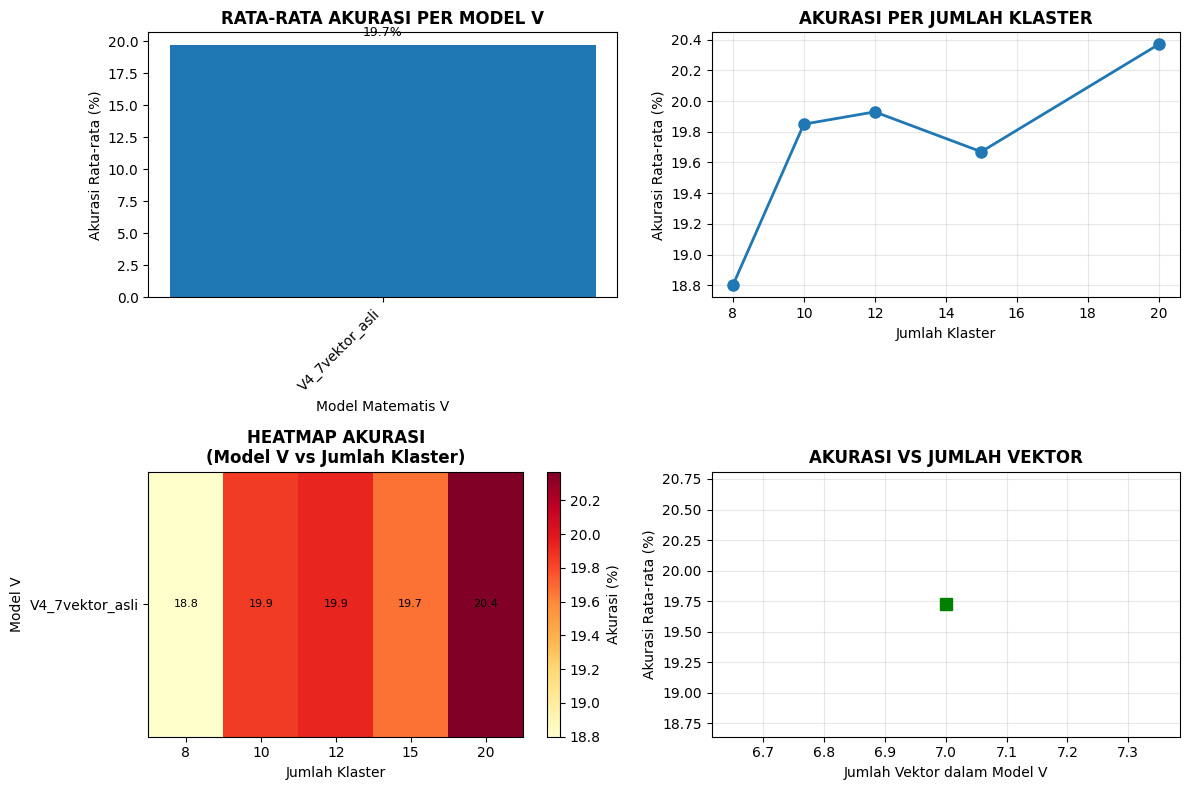

💾 Visualisasi eksperimen disimpan ke: C:/Users/Ahsan/Downloads/data/archive\cifar10_visualisasi_eksperimen.png

🏆 HASIL TERBAIK:
   Model V: V4_7vektor_asli
   Jumlah Vektor: 7
   Jumlah Klaster: 20
   Akurasi: 20.37%

TABEL RINGKASAN HASIL EKSPERIMEN

Rank | Model V                   | Vektor | Klaster | Akurasi  | Jml Gambar
---------------------------------------------------------------------------
   1 | V4_7vektor_asli           |      7 |      20 |   20.37% |      10000
   2 | V4_7vektor_asli           |      7 |      12 |   19.93% |      10000
   3 | V4_7vektor_asli           |      7 |      10 |   19.85% |      10000
   4 | V4_7vektor_asli           |      7 |      15 |   19.67% |      10000
   5 | V4_7vektor_asli           |      7 |       8 |   18.80% |      10000

📈 STATISTIK EKSPERIMEN:
   Total kombinasi yang diuji: 5
   Akurasi tertinggi: 20.37%
   Akurasi terendah: 18.80%
   Akurasi rata-rata: 19.72%

🏅 MODEL TERBAIK PER KATEGORI:
   7 vektor: V4_7vektor_asli (20.37% den

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pickle

# =============================================
# KONFIGURASI - CIFAR-10 DATASET (PATH DIESKSPOR KE DOWNLOADS/ARCHIVE)
# =============================================
base_path = "C:/Users/Ahsan/Downloads/data/archive"
cifar10_train_folder = os.path.join(base_path, "cifar10_train")
cifar10_test_folder = os.path.join(base_path, "cifar10_test")

# 10 kelas CIFAR-10
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# File output dengan path yang sesuai
output_excel = os.path.join(base_path, "cifar10_data_ekstraksi_rgb_10kelas.xlsx")
ecdf_output_csv = os.path.join(base_path, "cifar10_data_ecdf_rgb_10kelas.csv")
ecdf_intensity_output_excel = os.path.join(base_path, "cifar10_data_ecdf_intensitas_10kelas.xlsx")
conversion_output_excel = os.path.join(base_path, "cifar10_data_ecdf_cdf_konversi_10kelas.xlsx")
clustering_output_excel = os.path.join(base_path, "cifar10_hasil_clustering_10kelas.xlsx")
centroid_output_file = os.path.join(base_path, "cifar10_centroid_10kelas.pkl")

p = 16  # Ukuran resize gambar: p x p (sesuai CIFAR-10 asli)

# =============================================
# FUNGSI UTAMA UNTUK MEMPROSES GAMBAR
# =============================================

def process_image(image_path, label, gambar_ke):
    """
    Memproses satu gambar: resize ke p x p, ekstrak RGB, dan simpan ke Excel
    """
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Tidak bisa membaca gambar: {image_path}")
        return None
    
    # Resize gambar menjadi p x p
    img_resized = cv2.resize(img, (p, p))
    
    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Ekstrak channel R, G, B
    R = img_rgb[:, :, 0].flatten()
    G = img_rgb[:, :, 1].flatten()
    B = img_rgb[:, :, 2].flatten()
    
    # Hitung statistik
    hasil = {
        'filename': os.path.basename(image_path),
        'gambar_ke': gambar_ke,
        'label': label,
        'p': p,
        'total_pixels': p * p,
        'R_values': R,
        'G_values': G,
        'B_values': B,
        'avg_R': np.mean(R),
        'avg_G': np.mean(G),
        'avg_B': np.mean(B),
        'min_R': np.min(R),
        'max_R': np.max(R),
        'min_G': np.min(G),
        'max_G': np.max(G),
        'min_B': np.min(B),
        'max_B': np.max(B)
    }
    
    return hasil

def process_all_images_from_folder(folder_path, label):
    """
    Memproses semua gambar dalam folder untuk satu kelas
    """
    results = []
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return pd.DataFrame()
    
    image_files = [f for f in os.listdir(folder_path) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print(f"❌ Tidak ada gambar ditemukan di: {folder_path}")
        return pd.DataFrame()
    
    print(f"📁 Memproses {len(image_files)} gambar dari {folder_path} (label: {label})")
    
    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        
        result = process_image(image_path, label, i+1)
        if result is not None:
            results.append(result)
    
    # Konversi ke DataFrame
    if results:
        df = pd.DataFrame(results)
        print(f"✅ Berhasil memproses {len(df)} gambar dengan label: {label}")
        return df
    else:
        print(f"❌ Tidak ada hasil yang berhasil diproses dari {folder_path}")
        return pd.DataFrame()

def process_cifar10_dataset(base_folder, dataset_type="train"):
    """
    Memproses semua kelas CIFAR-10 dari folder base
    """
    all_dfs = []
    
    for class_name in cifar10_classes:
        class_folder = os.path.join(base_folder, class_name)
        df_class = process_all_images_from_folder(class_folder, class_name)
        if not df_class.empty:
            all_dfs.append(df_class)
    
    if all_dfs:
        df_combined = pd.concat(all_dfs, ignore_index=True)
        print(f"✅ Total {len(df_combined)} gambar diproses dari {dataset_type} dataset")
        return df_combined
    else:
        print(f"❌ Tidak ada data yang diproses dari {dataset_type} dataset")
        return pd.DataFrame()

def save_rgb_to_excel(df_rgb, output_path):
    """
    Menyimpan data RGB ke file Excel
    """
    # Buat DataFrame yang lebih sederhana untuk disimpan
    save_data = []
    for _, row in df_rgb.iterrows():
        save_data.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label': row['label'],
            'p': row['p'],
            'total_pixels': row['total_pixels'],
            'R_values': str(row['R_values'].tolist()),
            'G_values': str(row['G_values'].tolist()),
            'B_values': str(row['B_values'].tolist()),
            'avg_R': row['avg_R'],
            'avg_G': row['avg_G'],
            'avg_B': row['avg_B'],
            'min_R': row['min_R'],
            'max_R': row['max_R'],
            'min_G': row['min_G'],
            'max_G': row['max_G'],
            'min_B': row['min_B'],
            'max_B': row['max_B']
        })
    
    df_save = pd.DataFrame(save_data)
    df_save.to_excel(output_path, index=False)
    print(f"💾 Data RGB disimpan ke: {output_path}")

# =============================================
# FUNGSI ECDF
# =============================================

def calculate_ecdf(values):
    """
    Menghitung ECDF untuk suatu set nilai
    """
    if len(values) == 0:
        return np.array([]), np.array([])
    
    # Urutkan nilai
    sorted_values = np.sort(values)
    
    # Hitung ECDF
    n = len(sorted_values)
    ecdf = np.arange(1, n + 1) / n
    
    return sorted_values, ecdf

def calculate_ecdf_for_image(image_data):
    """
    Menghitung ECDF untuk sebuah gambar
    """
    filename = image_data['filename']
    j = image_data['gambar_ke']
    label = image_data['label']
    p_j = image_data['p']
    
    ecdf_data = {
        'filename': filename,
        'gambar_ke': j,
        'label': label,
        'p_j': p_j,
        'R': {'intensity': [], 'ecdf': []},
        'G': {'intensity': [], 'ecdf': []},
        'B': {'intensity': [], 'ecdf': []}
    }
    
    # Untuk setiap channel R, G, B
    for channel in ['R', 'G', 'B']:
        values = image_data[f'{channel}_values']
        
        if len(values) > 0:
            intensity, ecdf = calculate_ecdf(values)
            ecdf_data[channel]['intensity'] = intensity
            ecdf_data[channel]['ecdf'] = ecdf
    
    return ecdf_data

def calculate_all_ecdf(df_rgb):
    """
    Menghitung ECDF untuk semua gambar
    """
    ecdf_results = {}
    
    for _, row in df_rgb.iterrows():
        ecdf_data = calculate_ecdf_for_image(row)
        ecdf_results[row['filename']] = ecdf_data
    
    return ecdf_results

def save_ecdf_to_csv(ecdf_data, output_path):
    """
    Menyimpan data ECDF ke file CSV (bukan Excel) untuk handle data besar
    """
    save_data = []
    
    for filename, data in ecdf_data.items():
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            if len(channel_data['intensity']) > 0:
                for intensity, ecdf_val in zip(channel_data['intensity'], channel_data['ecdf']):
                    save_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'intensity': intensity,
                        'ecdf': ecdf_val,
                        'p_j': data['p_j']
                    })
    
    df_save = pd.DataFrame(save_data)
    
    # Simpan ke CSV bukan Excel
    df_save.to_csv(output_path, index=False)
    print(f"💾 Data ECDF disimpan ke: {output_path}")
    print(f"📊 Jumlah baris data ECDF: {len(df_save)}")

# =============================================
# FUNGSI MODEL MATEMATIS V DAN KONVERSI CDF
# =============================================

def create_mathematical_model_V(df_cdf):
    """
    Membuat model matematis V dari data CDF intensitas
    """
    model_V = {}
    
    # Channel R: intensitas 100, 150, 200
    for intensity in [100, 150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'R') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            model_V[f'R_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Channel G: intensitas 150, 200
    for intensity in [150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'G') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            model_V[f'G_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Channel B: intensitas 150, 200
    for intensity in [150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'B') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            model_V[f'B_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    print("✅ Model matematis V berhasil dibuat")
    print(f"🔧 Komponen model V: {list(model_V.keys())}")
    
    return model_V

def convert_ecdf_to_cdf_with_model_V(ecdf_value, model_key, model_V):
    """
    Mengkonversi nilai ECDF ke CDF menggunakan model matematis V
    """
    if model_key not in model_V:
        return None
    
    model_data = model_V[model_key]
    ecdf_values = model_data['ecdf_values']
    cdf_values = model_data['cdf_values']
    
    # Jika ECDF value di luar range model, return None
    if ecdf_value < ecdf_values[0] or ecdf_value > ecdf_values[-1]:
        return None
    
    # Cari posisi ECDF value dalam model
    idx = np.searchsorted(ecdf_values, ecdf_value, side='right') - 1
    
    # Return CDF value yang sesuai
    return cdf_values[idx]

def extract_and_convert_ecdf_data(ecdf_data, model_V):
    """
    Mengekstrak ECDF dari gambar pada intensitas tertentu dan mengkonversinya ke CDF menggunakan model V
    """
    conversion_results = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        # Ekstrak ECDF pada intensitas tertentu untuk semua channel
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target
                for intensity in [100, 150, 200]:
                    # Tentukan model_key berdasarkan channel dan intensitas
                    model_key = f'{channel}_{intensity}'
                    
                    # Skip jika model_key tidak ada di model_V
                    if model_key not in model_V:
                        continue
                    
                    # Cari nilai ECDF pada intensitas target
                    ecdf_val = 0.0
                    for m in range(len(intensity_values)):
                        if intensity < intensity_values[0]:
                            ecdf_val = 0.0
                            break
                        elif intensity >= intensity_values[m]:
                            if m == len(intensity_values) - 1 or intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        elif intensity >= intensity_values[-1]:
                            ecdf_val = 1.0
                            break
                    
                    # Konversi ECDF ke CDF menggunakan model V
                    cdf_val = convert_ecdf_to_cdf_with_model_V(ecdf_val, model_key, model_V)
                    
                    conversion_results.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val,
                        'cdf_value': cdf_val,
                        'model_key': model_key
                    })
    
    df_conversion = pd.DataFrame(conversion_results)
    return df_conversion

def save_conversion_data(ecdf_data, df_conversion, output_path):
    """
    Menyimpan data ECDF gambar dan CDF hasil konversi ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data konversi ECDF ke CDF (data kecil)
        df_conversion.to_excel(writer, sheet_name='Konversi_ECDF_ke_CDF', index=False)
        
        # Sheet 2: Ringkasan ECDF per gambar (data lebih kecil)
        summary_data = []
        for filename, data in ecdf_data.items():
            for channel in ['R', 'G', 'B']:
                channel_data = data[channel]
                if len(channel_data['intensity']) > 0:
                    summary_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'num_points': len(channel_data['intensity']),
                        'min_intensity': min(channel_data['intensity']),
                        'max_intensity': max(channel_data['intensity']),
                        'min_ecdf': min(channel_data['ecdf']),
                        'max_ecdf': max(channel_data['ecdf'])
                    })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Ringkasan_ECDF', index=False)
    
    print(f"💾 Data konversi CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI EKSTRAKSI ECDF PADA INTENSITAS TERTENTU
# =============================================

def extract_ecdf_at_intensities(ecdf_data, intensities=[100, 150, 200]):
    """
    Mengekstrak nilai ECDF pada intensitas tertentu untuk setiap gambar dan channel
    """
    ecdf_intensity_data = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target, cari nilai ECDF-nya
                for intensity in intensities:
                    ecdf_val = 0.0
                    
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                    else:
                        # Cari di segmen mana intensitas berada
                        for m in range(len(intensity_values) - 1):
                            if intensity_values[m] <= intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        else:
                            # Jika tidak ditemukan dalam loop, gunakan nilai terakhir
                            ecdf_val = ecdf_values[-1] if intensity >= intensity_values[-1] else 0.0
                    
                    ecdf_intensity_data.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val
                    })
    
    df_ecdf_intensities = pd.DataFrame(ecdf_intensity_data)
    return df_ecdf_intensities

def calculate_cdf_for_ecdf_intensities(df_ecdf_intensities):
    """
    Menghitung CDF untuk nilai ECDF pada intensitas tertentu per channel
    """
    cdf_data = []
    
    for channel in ['R', 'G', 'B']:
        for intensity in [100, 150, 200]:
            # Ambil nilai ECDF untuk channel dan intensitas tertentu
            ecdf_values = df_ecdf_intensities[
                (df_ecdf_intensities['channel'] == channel) & 
                (df_ecdf_intensities['intensity_target'] == intensity)
            ]['ecdf_value'].values
            
            if len(ecdf_values) > 0:
                # Urutkan nilai ECDF
                sorted_ecdf = np.sort(ecdf_values)
                
                # Hitung CDF
                cdf_values = np.arange(1, len(sorted_ecdf) + 1) / len(sorted_ecdf)
                
                # Simpan data
                for ecdf_val, cdf_val in zip(sorted_ecdf, cdf_values):
                    cdf_data.append({
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val,
                        'cdf_value': cdf_val
                    })
    
    df_cdf = pd.DataFrame(cdf_data)
    return df_cdf

def save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, output_path):
    """
    Menyimpan data ECDF pada intensitas tertentu dan CDF-nya ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data ECDF pada intensitas tertentu
        df_ecdf_intensities.to_excel(writer, sheet_name='ECDF_Intensitas', index=False)
        
        # Sheet 2: Data CDF dari ECDF intensitas
        df_cdf.to_excel(writer, sheet_name='CDF_ECDF_Intensitas', index=False)
    
    print(f"💾 Data ECDF intensitas dan CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI CENTROID DAN CLUSTERING UNTUK 10 KELAS
# =============================================

def calculate_class_centroids(df_features):
    """
    Menghitung centroid untuk setiap kelas dengan mengambil rata-rata dari semua gambar dalam kelas tersebut
    """
    centroids = {}
    
    # Filter hanya kolom fitur (exclude metadata)
    feature_columns = [col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']]
    
    # Dapatkan label unik yang sebenarnya ada di data
    actual_labels = df_features['label'].unique()
    
    for label in actual_labels:
        class_data = df_features[df_features['label'] == label]
        if len(class_data) > 0:
            # Hitung rata-rata untuk setiap fitur
            centroid_values = class_data[feature_columns].mean(axis=0).values
            centroids[label] = centroid_values
            print(f"✅ Centroid untuk kelas '{label}': {len(class_data)} gambar")
        else:
            print(f"❌ Tidak ada gambar untuk kelas '{label}'")
    
    return centroids, feature_columns

def save_centroids(centroids, feature_columns, output_path):
    """
    Menyimpan centroid ke file pickle
    """
    centroid_data = {
        'centroids': centroids,
        'feature_columns': feature_columns
    }
    
    with open(output_path, 'wb') as f:
        pickle.dump(centroid_data, f)
    
    print(f"💾 Centroid disimpan ke: {output_path}")

def load_centroids(input_path):
    """
    Memuat centroid dari file pickle
    """
    with open(input_path, 'rb') as f:
        centroid_data = pickle.load(f)
    
    print(f"💾 Centroid dimuat dari: {input_path}")
    return centroid_data['centroids'], centroid_data['feature_columns']

def prepare_features_for_clustering(df_conversion):
    """
    Menyiapkan fitur untuk clustering dari data CDF hasil konversi
    """
    # Group by filename untuk mendapatkan semua fitur CDF per gambar
    features_data = []
    
    for filename in df_conversion['filename'].unique():
        file_data = df_conversion[df_conversion['filename'] == filename]
        
        # Ekstrak semua nilai CDF untuk gambar ini
        feature_vector = {}
        feature_vector['filename'] = filename
        feature_vector['gambar_ke'] = file_data['gambar_ke'].iloc[0]
        feature_vector['label'] = file_data['label'].iloc[0]
        
        # Untuk setiap kombinasi channel dan intensitas
        for _, row in file_data.iterrows():
            key = f"{row['channel']}_{row['intensity_target']}"
            feature_vector[key] = row['cdf_value']
        
        features_data.append(feature_vector)
    
    df_features = pd.DataFrame(features_data)
    
    # DEBUG: Tampilkan label yang unik dan jumlahnya
    print("\n🔍 DEBUG - Label unik di df_features:")
    print(df_features['label'].value_counts())
    
    # Fill NaN values dengan 0
    df_features = df_features.fillna(0)
    
    return df_features

def perform_kmeans_clustering_10centroids(df_features, centroids_dict, feature_columns):
    """
    Melakukan K-means clustering dengan 10 centroid berdasarkan CDF hasil konversi
    Centroid diinisialisasi dengan rata-rata setiap kelas
    """
    print(f"\n🔍 Menyiapkan centroid dari rata-rata masing-masing kelas")
    
    # Filter hanya kolom fitur (exclude metadata)
    if len(feature_columns) == 0:
        print("❌ Tidak ada fitur yang ditemukan untuk clustering!")
        return None, None, None, []
    
    # Ekstrak matriks fitur
    X = df_features[feature_columns].values
    
    if len(centroids_dict) < 10:
        print(f"⚠️  Hanya {len(centroids_dict)} kelas yang memiliki centroid! Menggunakan centroid acak...")
        # Fallback: gunakan K-means dengan inisialisasi random
        kmeans = KMeans(n_clusters=10, random_state=42)
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
    else:
        # Siapkan initial centroids dari rata-rata kelas
        initial_centroids = np.array(list(centroids_dict.values()))
        
        print(f"📍 Shape initial centroids: {initial_centroids.shape}")
        print(f"🎯 Kelas yang digunakan: {list(centroids_dict.keys())}")
        
        # Lakukan K-means dengan inisialisasi centroid spesifik
        kmeans = KMeans(
            n_clusters=10,
            init=initial_centroids,
            n_init=1,  # Hanya gunakan inisialisasi yang diberikan
            max_iter=300,
            random_state=42
        )
        
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
        
        print("✅ K-means clustering dengan centroid berhasil!")
    
    # Tambahkan hasil clustering ke DataFrame
    df_features = df_features.copy()
    df_features['cluster'] = labels
    df_features['distance_to_centroid'] = kmeans.transform(X).min(axis=1)
    
    # Mapping cluster ke label berdasarkan centroid terdekat
    cluster_mapping = {}
    
    # Untuk setiap cluster, cari centroid kelas mana yang paling dekat
    for cluster_idx in range(len(centroids_dict)):
        if cluster_idx < len(centroids):  # Pastikan cluster_idx valid
            cluster_center = centroids[cluster_idx]
            
            # Hitung jarak ke setiap centroid kelas
            distances = {}
            for label, class_centroid in centroids_dict.items():
                distance = np.linalg.norm(cluster_center - class_centroid)
                distances[label] = distance
            
            # Pilih label dengan jarak terdekat
            if distances:  # Pastikan distances tidak kosong
                closest_label = min(distances, key=distances.get)
                cluster_mapping[cluster_idx] = closest_label
    
    print(f"🔀 Mapping cluster: {cluster_mapping}")
    
    df_features['cluster_label'] = df_features['cluster'].map(cluster_mapping)
    
    # Simpan informasi centroid yang digunakan
    centroid_info = []
    for cluster_idx, label in cluster_mapping.items():
        centroid_info.append({
            'cluster': cluster_idx,
            'cluster_label': label,
            'centroid_values': centroids[cluster_idx] if cluster_idx < len(centroids) else None
        })
    
    return df_features, kmeans, feature_columns, centroid_info

def analyze_clustering_results_10classes(df_features, df_conversion, centroid_info):
    """
    Menganalisis dan menampilkan hasil clustering untuk 10 kelas
    """
    print("\n" + "="*80)
    print("HASIL K-MEANS CLUSTERING - 10 KELAS CIFAR-10")
    print("="*80)
    
    # Tampilkan informasi centroid
    print("\n🎯 INFORMASI CENTROID:")
    for i, centroid in enumerate(centroid_info):
        print(f"   Cluster {centroid['cluster']}: {centroid['cluster_label']}")
    
    # Hitung akurasi clustering
    correct_predictions = 0
    total_predictions = len(df_features)
    
    clustering_results = []
    
    for _, row in df_features.iterrows():
        actual_label = row['label']
        predicted_label = row['cluster_label']
        is_correct = (actual_label == predicted_label)
        
        if is_correct:
            correct_predictions += 1
        
        clustering_results.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label_aktual': actual_label,
            'cluster_prediksi': row['cluster'],
            'label_prediksi': predicted_label,
            'benar': is_correct,
            'jarak_ke_centroid': row['distance_to_centroid']
        })
    
    accuracy = correct_predictions / total_predictions * 100 if total_predictions > 0 else 0
    
    print(f"\n📈 AKURASI CLUSTERING: {accuracy:.2f}%")
    print(f"   Benar: {correct_predictions}/{total_predictions}")
    
    # Tampilkan confusion matrix sederhana
    print("\n📊 CONFUSION MATRIX:")
    df_results = pd.DataFrame(clustering_results)
    if not df_results.empty:
        confusion_matrix = pd.crosstab(df_results['label_aktual'], df_results['label_prediksi'])
        print(confusion_matrix)
    
    return df_results, accuracy

def plot_clustering_results_10classes(df_features, feature_columns, centroid_info):
    """
    Membuat visualisasi hasil clustering untuk 10 kelas
    """
    print("\n" + "="*80)
    print("VISUALISASI HASIL CLUSTERING - 10 KELAS CIFAR-10")
    print("="*80)
    
    # Standardisasi fitur
    X = df_features[feature_columns].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Reduksi dimensi dengan PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Hitung batas yang sama untuk kedua plot
    x_min = min(X_pca[:, 0]) - 0.5
    x_max = max(X_pca[:, 0]) + 0.5
    y_min = min(X_pca[:, 1]) - 0.5
    y_max = max(X_pca[:, 1]) + 0.5
    
    # Buat plot dengan ukuran yang lebih besar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Warna untuk plot
    colors = {
        'airplane': 'blue', 'automobile': 'red', 'bird': 'green', 'cat': 'orange', 
        'deer': 'purple', 'dog': 'brown', 'frog': 'pink', 'horse': 'gray', 
        'ship': 'olive', 'truck': 'cyan'
    }
    
    # Plot 1: Label aktual
    actual_labels = df_features['label'].unique()
    for label in actual_labels:
        mask = df_features['label'] == label
        color = colors.get(label, 'black')  # Default black jika label tidak dikenali
        if mask.any():
            ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Aktual: {label}', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    ax1.set_title('LABEL AKTUAL (Ground Truth) - CIFAR-10', fontsize=14, fontweight='bold')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    
    # Plot 2: Hasil clustering
    cluster_labels = df_features['cluster_label'].unique()
    for cluster_label in cluster_labels:
        mask = df_features['cluster_label'] == cluster_label
        color = colors.get(cluster_label, 'black')  # Default black jika label tidak dikenali
        if mask.any():
            ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Cluster: {cluster_label}', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Tandai centroid dengan spesial marker
    print(f"🎯 Menampilkan {len(centroid_info)} centroid di plot...")
    centroid_markers = ['*', 'D', 's', '^', 'v', '<', '>', 'p', 'h', 'X']
    centroid_sizes = [400, 300, 350, 450, 500, 320, 380, 420, 470, 530]
    
    # Plot centroid (gunakan PCA transform dari centroid asli)
    for idx, centroid in enumerate(centroid_info):
        if centroid['centroid_values'] is not None:
            # Transform centroid ke ruang PCA
            centroid_scaled = scaler.transform([centroid['centroid_values']])
            centroid_pca = pca.transform(centroid_scaled)[0]
            
            marker = centroid_markers[idx % len(centroid_markers)]
            size = centroid_sizes[idx % len(centroid_sizes)]
            
            ax2.scatter(centroid_pca[0], centroid_pca[1], 
                       c='black', marker=marker, s=size,
                       label=f"Centroid: {centroid['cluster_label']}",
                       edgecolors='white', linewidth=2, zorder=5)
            
            print(f"   ✅ Centroid {idx}: {centroid['cluster_label']} di posisi {centroid_pca}")
    
    ax2.set_title('HASIL CLUSTERING K-MEANS - CIFAR-10', fontsize=14, fontweight='bold')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
    # Print variance explained oleh PCA
    print(f"\n📊 Variance yang dijelaskan oleh PCA:")
    print(f"   PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]:.2%})")
    print(f"   PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]:.2%})")
    print(f"   Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_):.2%})")

def save_clustering_results(df_features, df_results, accuracy, output_path):
    """
    Menyimpan hasil clustering ke file Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Fitur dan hasil clustering
        df_features.to_excel(writer, sheet_name='Fitur_dan_Clustering', index=False)
        
        # Sheet 2: Ringkasan hasil
        df_results.to_excel(writer, sheet_name='Hasil_Clustering', index=False)
        
        # Sheet 3: Statistik clustering
        accuracy_data = [{
            'total_gambar': len(df_features),
            'benar': len(df_results[df_results['benar'] == True]),
            'salah': len(df_results[df_results['benar'] == False]),
            'akurasi': accuracy
        }]
        df_accuracy = pd.DataFrame(accuracy_data)
        df_accuracy.to_excel(writer, sheet_name='Statistik', index=False)
    
    print(f"💾 Hasil clustering disimpan ke: {output_path}")

# =============================================
# FUNGSI PLOTTING CDF DAN ECDF INTENSITAS TERTENTU
# =============================================

def plot_cdf_intensities_all_images(df_cdf, output_dir):
    """
    Memplot CDF intensitas tertentu untuk semua gambar, per channel per intensitas (100, 150, 200)
    """
    print(f"\n📊 MEMPLOT CDF INTENSITAS TERTENTU UNTUK SEMUA GAMBAR...")
    
    # Buat direktori output jika belum ada
    os.makedirs(output_dir, exist_ok=True)
    
    # Intensitas yang akan diplot
    intensities = [100, 150, 200]
    
    # Plot untuk setiap channel
    for channel in ['R', 'G', 'B']:
        plt.figure(figsize=(15, 10))
        
        # Filter data untuk channel tertentu
        channel_data = df_cdf[df_cdf['channel'] == channel]
        
        # Plot untuk setiap intensitas
        for intensity in intensities:
            # Filter data untuk intensitas tertentu
            intensity_data = channel_data[channel_data['intensity_target'] == intensity]
            
            if not intensity_data.empty:
                # Urutkan berdasarkan ecdf_value untuk plotting yang rapi
                intensity_data = intensity_data.sort_values('ecdf_value')
                
                # Plot CDF
                plt.plot(intensity_data['ecdf_value'], intensity_data['cdf_value'], 
                        label=f'Intensitas {intensity}', linewidth=2, marker='o', markersize=3)
        
        plt.title(f'CDF INTENSITAS TERTENTU - CHANNEL {channel}\nSemua Gambar', 
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Nilai ECDF', fontsize=12)
        plt.ylabel('Nilai CDF', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.xticks(np.arange(0, 1.1, 0.1))
        plt.yticks(np.arange(0, 1.1, 0.1))
        
        # Simpan plot
        output_path = os.path.join(output_dir, f'cdf_intensitas_channel_{channel}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"   ✅ CDF intensitas channel {channel} disimpan: {output_path}")
    
    print(f"✅ Semua plot CDF intensitas disimpan di: {output_dir}")

def plot_ecdf_intensities_all_images(df_ecdf_intensities, output_dir):
    """
    Memplot ECDF intensitas tertentu untuk semua gambar, per channel per intensitas (100, 150, 200)
    """
    print(f"\n📊 MEMPLOT ECDF INTENSITAS TERTENTU UNTUK SEMUA GAMBAR...")
    
    # Buat direktori output jika belum ada
    os.makedirs(output_dir, exist_ok=True)
    
    # Intensitas yang akan diplot
    intensities = [100, 150, 200]
    
    # Plot untuk setiap channel
    for channel in ['R', 'G', 'B']:
        plt.figure(figsize=(15, 10))
        
        # Filter data untuk channel tertentu
        channel_data = df_ecdf_intensities[df_ecdf_intensities['channel'] == channel]
        
        # Plot untuk setiap intensitas
        for intensity in intensities:
            # Filter data untuk intensitas tertentu
            intensity_data = channel_data[channel_data['intensity_target'] == intensity]
            
            if not intensity_data.empty:
                # Hitung ECDF dari nilai ECDF pada intensitas tertentu
                ecdf_values = intensity_data['ecdf_value'].values
                
                if len(ecdf_values) > 0:
                    # Urutkan nilai ECDF
                    sorted_ecdf = np.sort(ecdf_values)
                    
                    # Hitung ECDF dari nilai ECDF (ECDF dari ECDF)
                    ecdf_of_ecdf = np.arange(1, len(sorted_ecdf) + 1) / len(sorted_ecdf)
                    
                    # Plot ECDF
                    plt.plot(sorted_ecdf, ecdf_of_ecdf, 
                            label=f'Intensitas {intensity}', linewidth=2, marker='s', markersize=3)
        
        plt.title(f'ECDF INTENSITAS TERTENTU - CHANNEL {channel}\nSemua Gambar', 
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel('Nilai ECDF pada Intensitas Tertentu', fontsize=12)
        plt.ylabel('ECDF', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.xticks(np.arange(0, 1.1, 0.1))
        plt.yticks(np.arange(0, 1.1, 0.1))
        
        # Simpan plot
        output_path = os.path.join(output_dir, f'ecdf_intensitas_channel_{channel}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"   ✅ ECDF intensitas channel {channel} disimpan: {output_path}")
    
    print(f"✅ Semua plot ECDF intensitas disimpan di: {output_dir}")

def plot_comparison_intensities(df_ecdf_intensities, df_cdf, output_dir):
    """
    Memplot perbandingan antara CDF dan ECDF intensitas tertentu dalam satu gambar
    """
    print(f"\n📊 MEMPLOT PERBANDINGAN CDF DAN ECDF INTENSITAS TERTENTU...")
    
    # Buat direktori output jika belum ada
    os.makedirs(output_dir, exist_ok=True)
    
    # Intensitas yang akan diplot
    intensities = [100, 150, 200]
    
    # Plot untuk setiap channel
    for channel in ['R', 'G', 'B']:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
        
        # ===== PLOT 1: CDF INTENSITAS =====
        channel_cdf_data = df_cdf[df_cdf['channel'] == channel]
        
        for intensity in intensities:
            intensity_cdf_data = channel_cdf_data[channel_cdf_data['intensity_target'] == intensity]
            
            if not intensity_cdf_data.empty:
                intensity_cdf_data = intensity_cdf_data.sort_values('ecdf_value')
                ax1.plot(intensity_cdf_data['ecdf_value'], intensity_cdf_data['cdf_value'], 
                        label=f'Intensitas {intensity}', linewidth=2, marker='o', markersize=4)
        
        ax1.set_title(f'CDF INTENSITAS TERTENTU\nChannel {channel}', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Nilai ECDF', fontsize=12)
        ax1.set_ylabel('Nilai CDF', fontsize=12)
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)
        ax1.set_xticks(np.arange(0, 1.1, 0.1))
        ax1.set_yticks(np.arange(0, 1.1, 0.1))
        
        # ===== PLOT 2: ECDF INTENSITAS =====
        channel_ecdf_data = df_ecdf_intensities[df_ecdf_intensities['channel'] == channel]
        
        for intensity in intensities:
            intensity_ecdf_data = channel_ecdf_data[channel_ecdf_data['intensity_target'] == intensity]
            
            if not intensity_ecdf_data.empty:
                ecdf_values = intensity_ecdf_data['ecdf_value'].values
                
                if len(ecdf_values) > 0:
                    sorted_ecdf = np.sort(ecdf_values)
                    ecdf_of_ecdf = np.arange(1, len(sorted_ecdf) + 1) / len(sorted_ecdf)
                    
                    ax2.plot(sorted_ecdf, ecdf_of_ecdf, 
                            label=f'Intensitas {intensity}', linewidth=2, marker='s', markersize=4)
        
        ax2.set_title(f'ECDF INTENSITAS TERTENTU\nChannel {channel}', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Nilai ECDF pada Intensitas Tertentu', fontsize=12)
        ax2.set_ylabel('ECDF', fontsize=12)
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        ax2.set_xticks(np.arange(0, 1.1, 0.1))
        ax2.set_yticks(np.arange(0, 1.1, 0.1))
        
        plt.tight_layout()
        
        # Simpan plot
        output_path = os.path.join(output_dir, f'perbandingan_cdf_ecdf_channel_{channel}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"   ✅ Perbandingan CDF-ECDF channel {channel} disimpan: {output_path}")
    
    print(f"✅ Semua plot perbandingan disimpan di: {output_dir}")

def plot_intensity_distribution_by_class(df_ecdf_intensities, output_dir):
    """
    Memplot distribusi nilai ECDF pada intensitas tertentu per kelas
    """
    print(f"\n📊 MEMPLOT DISTRIBUSI INTENSITAS PER KELAS...")
    
    # Buat direktori output jika belum ada
    os.makedirs(output_dir, exist_ok=True)
    
    # Intensitas yang akan diplot
    intensities = [100, 150, 200]
    
    # Plot untuk setiap channel
    for channel in ['R', 'G', 'B']:
        fig, axes = plt.subplots(2, 2, figsize=(20, 15))
        axes = axes.flatten()
        
        # Plot untuk setiap intensitas
        for idx, intensity in enumerate(intensities):
            if idx < len(axes):
                ax = axes[idx]
                
                # Filter data untuk channel dan intensitas tertentu
                channel_intensity_data = df_ecdf_intensities[
                    (df_ecdf_intensities['channel'] == channel) & 
                    (df_ecdf_intensities['intensity_target'] == intensity)
                ]
                
                if not channel_intensity_data.empty:
                    # Buat boxplot per kelas
                    class_data = []
                    class_labels = []
                    
                    for class_name in cifar10_classes:
                        class_ecdf = channel_intensity_data[channel_intensity_data['label'] == class_name]['ecdf_value']
                        if len(class_ecdf) > 0:
                            class_data.append(class_ecdf)
                            class_labels.append(class_name)
                    
                    if class_data:
                        box_plot = ax.boxplot(class_data, labels=class_labels, patch_artist=True)
                        
                        # Warna untuk boxplot
                        colors = plt.cm.Set3(np.linspace(0, 1, len(class_data)))
                        for patch, color in zip(box_plot['boxes'], colors):
                            patch.set_facecolor(color)
                        
                        ax.set_title(f'Distribusi ECDF - {channel} Intensitas {intensity}', 
                                   fontsize=12, fontweight='bold')
                        ax.set_ylabel('Nilai ECDF', fontsize=10)
                        ax.tick_params(axis='x', rotation=45)
                        ax.grid(True, alpha=0.3)
        
        # Sembunyikan subplot yang tidak digunakan
        for idx in range(len(intensities), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        
        # Simpan plot
        output_path = os.path.join(output_dir, f'distribusi_intensitas_per_kelas_{channel}.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()
        
        print(f"   ✅ Distribusi intensitas per kelas channel {channel} disimpan: {output_path}")
    
    print(f"✅ Semua plot distribusi per kelas disimpan di: {output_dir}")

# =============================================
# FUNGSI UTAMA UNTUK CIFAR-10
# =============================================

def main_cifar10_training():
    """
    Fungsi utama untuk memproses data training CIFAR-10 (10 kelas)
    """
    print("PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS INTENSITAS - 10 KELAS CIFAR-10 (TRAINING)")
    print("=" * 80)
    
    # 1. Proses gambar training dari 10 kelas CIFAR-10
    print("\n1. PROSES GAMBAR TRAINING DARI 10 KELAS CIFAR-10")
    df_train = process_cifar10_dataset(cifar10_train_folder, "training")
    
    if df_train.empty:
        print("❌ Tidak ada data training yang diproses. Periksa path folder dan file gambar.")
        return None, None
    
    print(f"\n📊 Total gambar training diproses: {len(df_train)}")
    for class_name in cifar10_classes:
        count = len(df_train[df_train['label'] == class_name])
        print(f"  - {class_name}: {count} gambar")
    
    # 2. Simpan data RGB training ke Excel
    print(f"\n2. MENYIMPAN DATA RGB TRAINING KE EXCEL: {output_excel}")
    save_rgb_to_excel(df_train, output_excel)
    
    # 3. Hitung ECDF untuk semua gambar training
    print("\n3. MENGHITUNG ECDF UNTUK SEMUA GAMBAR TRAINING")
    train_ecdf_results = calculate_all_ecdf(df_train)
    
    # 4. Simpan data ECDF training ke CSV
    print(f"\n4. MENYIMPAN DATA ECDF TRAINING KE CSV: {ecdf_output_csv}")
    save_ecdf_to_csv(train_ecdf_results, ecdf_output_csv)
    
    # 5. Ekstrak nilai ECDF pada intensitas tertentu dari training
    print("\n5. EKSTRAKSI NILAI ECDF PADA INTENSITAS 100, 150, 200 DARI TRAINING")
    df_ecdf_intensities = extract_ecdf_at_intensities(train_ecdf_results)
    
    # 6. Hitung CDF untuk nilai ECDF pada intensitas tertentu dari training
    print("\n6. MENGHITUNG CDF UNTUK NILAI ECDF PADA INTENSITAS TERTENTU DARI TRAINING")
    df_cdf = calculate_cdf_for_ecdf_intensities(df_ecdf_intensities)
    
    # 7. Simpan data ECDF intensitas dan CDF training
    print(f"\n7. MENYIMPAN DATA ECDF INTENSITAS DAN CDF TRAINING: {ecdf_intensity_output_excel}")
    save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, ecdf_intensity_output_excel)
    
    # =============================================
    # PLOTTING CDF DAN ECDF INTENSITAS TERTENTU
    # =============================================
    
    # Buat direktori untuk menyimpan plot
    plot_dir = os.path.join(base_path, "cifar10_plots_intensitas")
    
    # 7a. Plot CDF intensitas tertentu untuk semua gambar
    print(f"\n7a. MEMPLOT CDF INTENSITAS TERTENTU UNTUK SEMUA GAMBAR")
    plot_cdf_intensities_all_images(df_cdf, os.path.join(plot_dir, "cdf_intensitas"))
    
    # 7b. Plot ECDF intensitas tertentu untuk semua gambar
    print(f"\n7b. MEMPLOT ECDF INTENSITAS TERTENTU UNTUK SEMUA GAMBAR")
    plot_ecdf_intensities_all_images(df_ecdf_intensities, os.path.join(plot_dir, "ecdf_intensitas"))
    
    # 7c. Plot perbandingan CDF dan ECDF intensitas tertentu
    print(f"\n7c. MEMPLOT PERBANDINGAN CDF DAN ECDF INTENSITAS TERTENTU")
    plot_comparison_intensities(df_ecdf_intensities, df_cdf, os.path.join(plot_dir, "perbandingan"))
    
    # 7d. Plot distribusi intensitas per kelas
    print(f"\n7d. MEMPLOT DISTRIBUSI INTENSITAS PER KELAS")
    plot_intensity_distribution_by_class(df_ecdf_intensities, os.path.join(plot_dir, "distribusi_per_kelas"))
    
    # 8. Membuat model matematis V dari data CDF training
    print("\n8. MEMBUAT MODEL MATEMATIS V DARI DATA CDF INTENSITAS TRAINING")
    model_V = create_mathematical_model_V(df_cdf)
    
    # 9. Ekstrak ECDF dari gambar training dan konversi ke CDF menggunakan model V
    print("\n9. EKSTRAKSI ECDF DARI GAMBAR TRAINING DAN KONVERSI KE CDF MENGGUNAKAN MODEL V")
    df_conversion = extract_and_convert_ecdf_data(train_ecdf_results, model_V)
    
    # 10. Simpan data konversi CDF training
    print(f"\n10. MENYIMPAN DATA KONVERSI CDF TRAINING: {conversion_output_excel}")
    save_conversion_data(train_ecdf_results, df_conversion, conversion_output_excel)
    
    # 11. Persiapan fitur untuk clustering dari CDF hasil konversi training
    print("\n11. PERSIAPAN FITUR UNTUK CLUSTERING DARI CDF HASIL KONVERSI TRAINING")
    df_features = prepare_features_for_clustering(df_conversion)
    
    if df_features.empty:
        print("❌ Tidak ada fitur yang dapat dipersiapkan untuk clustering!")
        return None, None
    
    print(f"   Jumlah gambar training untuk clustering: {len(df_features)}")
    print(f"   Jumlah fitur per gambar: {len([col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']])}")
    
    # 12. Hitung centroid dari data training
    print("\n12. MENGHITUNG CENTROID DARI DATA TRAINING")
    centroids_dict, feature_columns = calculate_class_centroids(df_features)
    
    # 13. Simpan centroid ke file
    print(f"\n13. MENYIMPAN CENTROID: {centroid_output_file}")
    save_centroids(centroids_dict, feature_columns, centroid_output_file)
    
    print("\n" + "="*80)
    print("🎉 PROSES TRAINING SELESAI UNTUK 10 KELAS CIFAR-10!")
    print("="*80)
    
    return model_V, centroids_dict

# =============================================
# FUNGSI EKSPERIMEN VARIASI MODEL V DAN JUMLAH KLASTER
# =============================================

def create_varied_mathematical_models(df_cdf):
    """
    Membuat berbagai variasi model matematis V untuk eksperimen
    """
    models = {}
    
    # Model 1: Intensitas 100 untuk R, G, B (3 vektor)
    models['V1_100_RGB'] = {}
    for channel in ['R', 'G', 'B']:
        intensity = 100
        channel_data = df_cdf[(df_cdf['channel'] == channel) & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            models['V1_100_RGB'][f'{channel}_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Model 2: Intensitas 150 untuk R, G (2 vektor)
    models['V2_150_RG'] = {}
    for channel in ['R', 'G']:
        intensity = 150
        channel_data = df_cdf[(df_cdf['channel'] == channel) & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            models['V2_150_RG'][f'{channel}_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Model 3: Intensitas 200 untuk R, G (2 vektor)
    models['V3_200_RG'] = {}
    for channel in ['R', 'G']:
        intensity = 200
        channel_data = df_cdf[(df_cdf['channel'] == channel) & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            models['V3_200_RG'][f'{channel}_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Model 4: 7 vektor asli (R_100, R_150, R_200, G_150, G_200, B_150, B_200)
    models['V4_7vektor_asli'] = {}
    # Channel R: intensitas 100, 150, 200
    for intensity in [100, 150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'R') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            models['V4_7vektor_asli'][f'R_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Channel G: intensitas 150, 200
    for intensity in [150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'G') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            models['V4_7vektor_asli'][f'G_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Channel B: intensitas 150, 200
    for intensity in [150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'B') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            models['V4_7vektor_asli'][f'B_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Model 5: Intensitas 100, 150, 200 untuk semua channel (9 vektor)
    models['V5_100_150_200_RGB'] = {}
    for channel in ['R', 'G', 'B']:
        for intensity in [100, 150, 200]:
            channel_data = df_cdf[(df_cdf['channel'] == channel) & (df_cdf['intensity_target'] == intensity)]
            if not channel_data.empty:
                models['V5_100_150_200_RGB'][f'{channel}_{intensity}'] = {
                    'ecdf_values': channel_data['ecdf_value'].values,
                    'cdf_values': channel_data['cdf_value'].values
                }
    
    # Model 6: Intensitas 150 untuk semua channel (3 vektor)
    models['V6_150_RGB'] = {}
    for channel in ['R', 'G', 'B']:
        intensity = 150
        channel_data = df_cdf[(df_cdf['channel'] == channel) & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            models['V6_150_RGB'][f'{channel}_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    print("✅ Berhasil membuat berbagai variasi model matematis V")
    for model_name, model_data in models.items():
        print(f"   {model_name}: {len(model_data)} vektor")
    
    return models

def prepare_features_with_varied_models(df_conversion, model_V, model_name):
    """
    Menyiapkan fitur untuk clustering dengan model V yang divariasikan
    """
    features_data = []
    
    for filename in df_conversion['filename'].unique():
        file_data = df_conversion[df_conversion['filename'] == filename]
        
        feature_vector = {}
        feature_vector['filename'] = filename
        feature_vector['gambar_ke'] = file_data['gambar_ke'].iloc[0]
        feature_vector['label'] = file_data['label'].iloc[0]
        
        # Hanya ambil fitur yang ada dalam model V yang dipilih
        for _, row in file_data.iterrows():
            key = f"{row['channel']}_{row['intensity_target']}"
            if key in model_V:  # Hanya gunakan jika key ada dalam model
                feature_vector[key] = row['cdf_value']
        
        features_data.append(feature_vector)
    
    df_features = pd.DataFrame(features_data)
    df_features = df_features.fillna(0)
    
    print(f"   Model {model_name}: {len([col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']])} fitur")
    
    return df_features

def perform_kmeans_with_varied_clusters(df_features, centroids_dict, feature_columns, n_clusters):
    """
    Melakukan K-means clustering dengan jumlah klaster yang divariasikan
    """
    # Filter hanya kolom fitur
    if len(feature_columns) == 0:
        return None, None, None, []
    
    X = df_features[feature_columns].values
    
    if len(centroids_dict) < n_clusters:
        # Jika jumlah centroid kelas kurang dari n_clusters, gunakan random initialization
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        print(f"   ⚠️  Menggunakan inisialisasi random untuk {n_clusters} klaster")
    else:
        # Gunakan centroid dari kelas yang ada sebagai initial
        initial_centroids = np.array(list(centroids_dict.values())[:n_clusters])
        kmeans = KMeans(
            n_clusters=n_clusters,
            init=initial_centroids,
            n_init=1,
            max_iter=300,
            random_state=42
        )
        print(f"   ✅ Menggunakan {n_clusters} centroid dari kelas sebagai inisialisasi")
    
    labels = kmeans.fit_predict(X)
    centroids = kmeans.cluster_centers_
    
    # Tambahkan hasil clustering ke DataFrame
    df_features = df_features.copy()
    df_features['cluster'] = labels
    df_features['distance_to_centroid'] = kmeans.transform(X).min(axis=1)
    
    # Mapping cluster ke label berdasarkan centroid terdekat
    cluster_mapping = {}
    for cluster_idx in range(n_clusters):
        if cluster_idx < len(centroids):
            cluster_center = centroids[cluster_idx]
            
            distances = {}
            for label, class_centroid in centroids_dict.items():
                distance = np.linalg.norm(cluster_center - class_centroid)
                distances[label] = distance
            
            if distances:
                closest_label = min(distances, key=distances.get)
                cluster_mapping[cluster_idx] = closest_label
    
    df_features['cluster_label'] = df_features['cluster'].map(cluster_mapping)
    
    # Simpan informasi centroid
    centroid_info = []
    for cluster_idx, label in cluster_mapping.items():
        centroid_info.append({
            'cluster': cluster_idx,
            'cluster_label': label,
            'centroid_values': centroids[cluster_idx] if cluster_idx < len(centroids) else None
        })
    
    return df_features, kmeans, feature_columns, centroid_info

def calculate_clustering_accuracy(df_features):
    """
    Menghitung akurasi clustering
    """
    correct_predictions = 0
    total_predictions = len(df_features)
    
    for _, row in df_features.iterrows():
        actual_label = row['label']
        predicted_label = row['cluster_label']
        if actual_label == predicted_label:
            correct_predictions += 1
    
    accuracy = correct_predictions / total_predictions * 100 if total_predictions > 0 else 0
    return accuracy

def run_varied_experiments(train_ecdf_results, test_ecdf_results, df_cdf, centroids_dict_full):
    """
    Menjalankan eksperimen dengan variasi model V dan jumlah klaster
    """
    print("\n" + "="*80)
    print("EKSPERIMEN VARIASI MODEL V DAN JUMLAH KLASTER")
    print("="*80)
    
    # Buat berbagai variasi model V
    varied_models = create_varied_mathematical_models(df_cdf)
    
    # Variasi jumlah klaster yang akan diuji
    cluster_variations = [8, 10, 12, 15, 20]
    
    results = []
    
    # Untuk setiap model V
    for model_name, model_V in varied_models.items():
        print(f"\n🔬 Menguji model: {model_name}")
        print(f"   Vektor yang digunakan: {list(model_V.keys())}")
        
        # Ekstrak dan konversi ECDF ke CDF menggunakan model V untuk data testing
        df_conversion_test = extract_and_convert_ecdf_data(test_ecdf_results, model_V)
        
        if df_conversion_test.empty:
            print(f"   ❌ Tidak ada data konversi untuk model {model_name}")
            continue
        
        # Siapkan fitur untuk model ini
        df_features_test = prepare_features_with_varied_models(df_conversion_test, model_V, model_name)
        
        if df_features_test.empty:
            print(f"   ❌ Tidak ada fitur untuk model {model_name}")
            continue
        
        feature_columns = [col for col in df_features_test.columns if col not in ['filename', 'gambar_ke', 'label']]
        
        # Untuk setiap variasi jumlah klaster
        for n_clusters in cluster_variations:
            print(f"   🎯 Menguji dengan {n_clusters} klaster...")
            
            try:
                # Lakukan clustering dengan jumlah klaster yang divariasikan
                df_features_clustered, kmeans, feature_columns, centroid_info = perform_kmeans_with_varied_clusters(
                    df_features_test, centroids_dict_full, feature_columns, n_clusters
                )
                
                if df_features_clustered is not None:
                    # Hitung akurasi
                    accuracy = calculate_clustering_accuracy(df_features_clustered)
                    
                    results.append({
                        'model_V': model_name,
                        'jumlah_vektor': len(model_V),
                        'vektor_used': ', '.join(model_V.keys()),
                        'jumlah_klaster': n_clusters,
                        'akurasi': accuracy,
                        'jumlah_gambar': len(df_features_test)
                    })
                    
                    print(f"      ✅ Akurasi: {accuracy:.2f}%")
                else:
                    print(f"      ❌ Clustering gagal untuk {n_clusters} klaster")
                    
            except Exception as e:
                print(f"      ❌ Error: {e}")
                continue
    
    # Buat DataFrame hasil
    df_results = pd.DataFrame(results)
    
    # Simpan hasil eksperimen
    output_path = os.path.join(base_path, "cifar10_hasil_eksperimen_variasi.xlsx")
    df_results.to_excel(output_path, index=False)
    print(f"\n💾 Hasil eksperimen disimpan ke: {output_path}")
    
    return df_results

def plot_experiment_results(df_results):
    """
    Membuat visualisasi hasil eksperimen variasi model V dan jumlah klaster
    """
    print("\n📊 MEMBUAT VISUALISASI HASIL EKSPERIMEN...")
    
    if df_results.empty:
        print("❌ Tidak ada hasil eksperimen untuk diplot")
        return
    
    # Plot 1: Akurasi per model V (rata-rata untuk semua jumlah klaster)
    plt.figure(figsize=(12, 8))
    
    # Hitung rata-rata akurasi per model
    model_accuracy = df_results.groupby('model_V')['akurasi'].mean().sort_values(ascending=False)
    
    plt.subplot(2, 2, 1)
    bars = plt.bar(range(len(model_accuracy)), model_accuracy.values)
    plt.title('RATA-RATA AKURASI PER MODEL V', fontsize=12, fontweight='bold')
    plt.xlabel('Model Matematis V')
    plt.ylabel('Akurasi Rata-rata (%)')
    plt.xticks(range(len(model_accuracy)), model_accuracy.index, rotation=45, ha='right')
    
    # Tambahkan nilai di atas bar
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{model_accuracy.values[i]:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: Akurasi per jumlah klaster (rata-rata untuk semua model)
    plt.subplot(2, 2, 2)
    cluster_accuracy = df_results.groupby('jumlah_klaster')['akurasi'].mean()
    plt.plot(cluster_accuracy.index, cluster_accuracy.values, marker='o', linewidth=2, markersize=8)
    plt.title('AKURASI PER JUMLAH KLASTER', fontsize=12, fontweight='bold')
    plt.xlabel('Jumlah Klaster')
    plt.ylabel('Akurasi Rata-rata (%)')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Heatmap akurasi (model vs jumlah klaster)
    plt.subplot(2, 2, 3)
    pivot_table = df_results.pivot_table(values='akurasi', index='model_V', columns='jumlah_klaster', aggfunc='mean')
    im = plt.imshow(pivot_table.values, cmap='YlOrRd', aspect='auto')
    plt.colorbar(im, label='Akurasi (%)')
    plt.title('HEATMAP AKURASI\n(Model V vs Jumlah Klaster)', fontsize=12, fontweight='bold')
    plt.xlabel('Jumlah Klaster')
    plt.ylabel('Model V')
    plt.xticks(range(len(pivot_table.columns)), pivot_table.columns)
    plt.yticks(range(len(pivot_table.index)), pivot_table.index)
    
    # Tambahkan nilai dalam heatmap
    for i in range(len(pivot_table.index)):
        for j in range(len(pivot_table.columns)):
            plt.text(j, i, f'{pivot_table.iloc[i, j]:.1f}', 
                    ha='center', va='center', fontsize=8, 
                    color='white' if pivot_table.iloc[i, j] > 50 else 'black')
    
    # Plot 4: Akurasi vs jumlah vektor
    plt.subplot(2, 2, 4)
    vector_accuracy = df_results.groupby('jumlah_vektor')['akurasi'].mean()
    plt.plot(vector_accuracy.index, vector_accuracy.values, marker='s', linewidth=2, markersize=8, color='green')
    plt.title('AKURASI VS JUMLAH VEKTOR', fontsize=12, fontweight='bold')
    plt.xlabel('Jumlah Vektor dalam Model V')
    plt.ylabel('Akurasi Rata-rata (%)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Simpan plot
    output_path = os.path.join(base_path, "cifar10_visualisasi_eksperimen.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"💾 Visualisasi eksperimen disimpan ke: {output_path}")
    
    # Tampilkan hasil terbaik
    best_result = df_results.loc[df_results['akurasi'].idxmax()]
    print(f"\n🏆 HASIL TERBAIK:")
    print(f"   Model V: {best_result['model_V']}")
    print(f"   Jumlah Vektor: {best_result['jumlah_vektor']}")
    print(f"   Jumlah Klaster: {best_result['jumlah_klaster']}")
    print(f"   Akurasi: {best_result['akurasi']:.2f}%")

def print_experiment_summary_table(df_results):
    """
    Mencetak tabel ringkasan hasil eksperimen
    """
    print("\n" + "="*80)
    print("TABEL RINGKASAN HASIL EKSPERIMEN")
    print("="*80)
    
    if df_results.empty:
        print("❌ Tidak ada hasil eksperimen")
        return
    
    # Urutkan berdasarkan akurasi tertinggi
    df_sorted = df_results.sort_values('akurasi', ascending=False)
    
    # Tampilkan tabel
    print("\nRank | Model V                   | Vektor | Klaster | Akurasi  | Jml Gambar")
    print("-" * 75)
    
    for i, (_, row) in enumerate(df_sorted.head(15).iterrows(), 1):
        model_display = row['model_V'][:25] + "..." if len(row['model_V']) > 25 else row['model_V']
        print(f"{i:4} | {model_display:25} | {row['jumlah_vektor']:6} | {row['jumlah_klaster']:7} | {row['akurasi']:7.2f}% | {row['jumlah_gambar']:10}")
    
    # Statistik tambahan
    print("\n📈 STATISTIK EKSPERIMEN:")
    print(f"   Total kombinasi yang diuji: {len(df_results)}")
    print(f"   Akurasi tertinggi: {df_results['akurasi'].max():.2f}%")
    print(f"   Akurasi terendah: {df_results['akurasi'].min():.2f}%")
    print(f"   Akurasi rata-rata: {df_results['akurasi'].mean():.2f}%")
    
    # Model terbaik per jumlah vektor
    print(f"\n🏅 MODEL TERBAIK PER KATEGORI:")
    best_by_vectors = df_results.loc[df_results.groupby('jumlah_vektor')['akurasi'].idxmax()]
    for _, row in best_by_vectors.iterrows():
        print(f"   {row['jumlah_vektor']} vektor: {row['model_V']} ({row['akurasi']:.2f}% dengan {row['jumlah_klaster']} klaster)")


def main_cifar10_testing(model_V, centroids_dict):
    """
    Fungsi utama untuk memproses data testing CIFAR-10 (10 kelas)
    """
    print("\n\nPROSES TESTING DAN CLUSTERING - 10 KELAS CIFAR-10 (TESTING)")
    print("=" * 80)
    
    # 1. Proses gambar testing dari 10 kelas CIFAR-10
    print("\n1. PROSES GAMBAR TESTING DARI 10 KELAS CIFAR-10")
    df_test = process_cifar10_dataset(cifar10_test_folder, "testing")
    
    if df_test.empty:
        print("❌ Tidak ada data testing yang diproses. Periksa path folder dan file gambar.")
        return
    
    print(f"\n📊 Total gambar testing diproses: {len(df_test)}")
    for class_name in cifar10_classes:
        count = len(df_test[df_test['label'] == class_name])
        print(f"  - {class_name}: {count} gambar")
    
    # 2. Hitung ECDF untuk semua gambar testing
    print("\n2. MENGHITUNG ECDF UNTUK SEMUA GAMBAR TESTING")
    test_ecdf_results = calculate_all_ecdf(df_test)
    
    # 3. Ekstrak ECDF dari gambar testing dan konversi ke CDF menggunakan model V dari training
    print("\n3. EKSTRAKSI ECDF DARI GAMBAR TESTING DAN KONVERSI KE CDF MENGGUNAKAN MODEL V")
    df_conversion_test = extract_and_convert_ecdf_data(test_ecdf_results, model_V)
    
    # 4. Persiapan fitur untuk clustering dari CDF hasil konversi testing
    print("\n4. PERSIAPAN FITUR UNTUK CLUSTERING DARI CDF HASIL KONVERSI TESTING")
    df_features_test = prepare_features_for_clustering(df_conversion_test)
    
    if df_features_test.empty:
        print("❌ Tidak ada fitur yang dapat dipersiapkan untuk clustering testing!")
        return
    
    print(f"   Jumlah gambar testing untuk clustering: {len(df_features_test)}")
    
    # 5. Melakukan K-means clustering dengan centroid dari training
    print("\n5. MELAKUKAN K-MEANS CLUSTERING DENGAN CENTROID DARI TRAINING")
    feature_columns = [col for col in df_features_test.columns if col not in ['filename', 'gambar_ke', 'label']]
    
    df_features_test, kmeans, feature_columns, centroid_info = perform_kmeans_clustering_10centroids(
        df_features_test, centroids_dict, feature_columns
    )
    
    if df_features_test is None:
        print("❌ Clustering testing gagal!")
        return
    
    # 6. Analisis hasil clustering testing
    print("\n6. ANALISIS HASIL CLUSTERING TESTING")
    df_results, accuracy = analyze_clustering_results_10classes(df_features_test, df_conversion_test, centroid_info)
    
    # 7. Visualisasi hasil clustering testing
    print("\n7. VISUALISASI HASIL CLUSTERING TESTING")
    plot_clustering_results_10classes(df_features_test, feature_columns, centroid_info)
    
    # 8. Simpan hasil clustering testing
    print(f"\n8. MENYIMPAN HASIL CLUSTERING TESTING: {clustering_output_excel}")
    save_clustering_results(df_features_test, df_results, accuracy, clustering_output_excel)
    
    # =============================================
    # EKSPERIMEN VARIASI MODEL V DAN JUMLAH KLASTER
    # =============================================
    
    # 9. Jalankan eksperimen dengan variasi model V dan jumlah klaster
    print("\n9. EKSPERIMEN VARIASI MODEL V DAN JUMLAH KLASTER")
    
    # Baca data CDF training untuk membuat variasi model
    df_cdf_train = pd.read_excel(ecdf_intensity_output_excel, sheet_name='CDF_ECDF_Intensitas')
    
    # Jalankan eksperimen
    df_experiment_results = run_varied_experiments(
        None,  # train_ecdf_results tidak diperlukan untuk eksperimen testing
        test_ecdf_results, 
        df_cdf_train, 
        centroids_dict
    )
    
    # 10. Visualisasi dan analisis hasil eksperimen
    print("\n10. ANALISIS HASIL EKSPERIMEN")
    plot_experiment_results(df_experiment_results)
    print_experiment_summary_table(df_experiment_results)
    
    print("\n" + "="*80)
    print("🎉 PROSES TESTING SELESAI UNTUK 10 KELAS CIFAR-10!")
    print("="*80)
    
    # Ringkasan akhir
    print("\n📊 RINGKASAN HASIL TESTING:")
    print(f"   - Total gambar testing diproses: {len(df_test)}")
    print(f"   - Akurasi clustering dasar: {accuracy:.2f}%")
    print(f"   - File output:")
    print(f"     * Data RGB Training: {output_excel}")
    print(f"     * Data ECDF Training (CSV): {ecdf_output_csv}")
    print(f"     * Data ECDF Intensitas Training: {ecdf_intensity_output_excel}")
    print(f"     * Data Konversi CDF Training: {conversion_output_excel}")
    print(f"     * Centroid: {centroid_output_file}")
    print(f"     * Hasil Clustering Testing: {clustering_output_excel}")
    print(f"     * Hasil Eksperimen Variasi: {os.path.join(base_path, 'cifar10_hasil_eksperimen_variasi.xlsx')}")

def main_cifar10_full():
    """
    Fungsi utama untuk menjalankan proses lengkap CIFAR-10
    """
    # Jalankan proses training
    model_V, centroids_dict = main_cifar10_training()
    
    if model_V is None or centroids_dict is None:
        print("❌ Proses training gagal!")
        return
    
    # Jalankan proses testing
    main_cifar10_testing(model_V, centroids_dict)

if __name__ == "__main__":
    # Jalankan proses lengkap CIFAR-10
    main_cifar10_full()

PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS INTENSITAS - 10 KELAS CIFAR-10 (TRAINING)

1. PROSES GAMBAR TRAINING DARI 10 KELAS CIFAR-10
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\airplane (label: airplane)
✅ Berhasil memproses 5000 gambar dengan label: airplane
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\automobile (label: automobile)
✅ Berhasil memproses 5000 gambar dengan label: automobile
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\bird (label: bird)
✅ Berhasil memproses 5000 gambar dengan label: bird
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\cat (label: cat)
✅ Berhasil memproses 5000 gambar dengan label: cat
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train\deer (label: deer)
✅ Berhasil memproses 5000 gambar dengan label: deer
📁 Memproses 5000 gambar dari C:/Users/Ahsan/Downloads/data/archive\cifar10_train

c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\ProgramData\anaconda3\envs\cifar10\lib\subprocess.py", line 951, in __init__
 

✅ K-means clustering dengan centroid berhasil!
🔀 Mapping cluster: {0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'frog', 5: 'frog', 6: 'frog', 7: 'airplane', 8: 'airplane', 9: 'truck'}

6. ANALISIS HASIL CLUSTERING TESTING

HASIL K-MEANS CLUSTERING - 10 KELAS CIFAR-10

🎯 INFORMASI CENTROID:
   Cluster 0: airplane
   Cluster 1: automobile
   Cluster 2: bird
   Cluster 3: cat
   Cluster 4: frog
   Cluster 5: frog
   Cluster 6: frog
   Cluster 7: airplane
   Cluster 8: airplane
   Cluster 9: truck

📈 AKURASI CLUSTERING: 19.85%
   Benar: 1985/10000

📊 CONFUSION MATRIX:
label_prediksi  airplane  automobile  bird  cat  frog  truck
label_aktual                                                
airplane             551         132    54   50   119     94
automobile           225         271    14  148   136    206
bird                 270         123    90   72   390     55
cat                  270         177    33  133   256    131
deer                 157          97    73   83   54

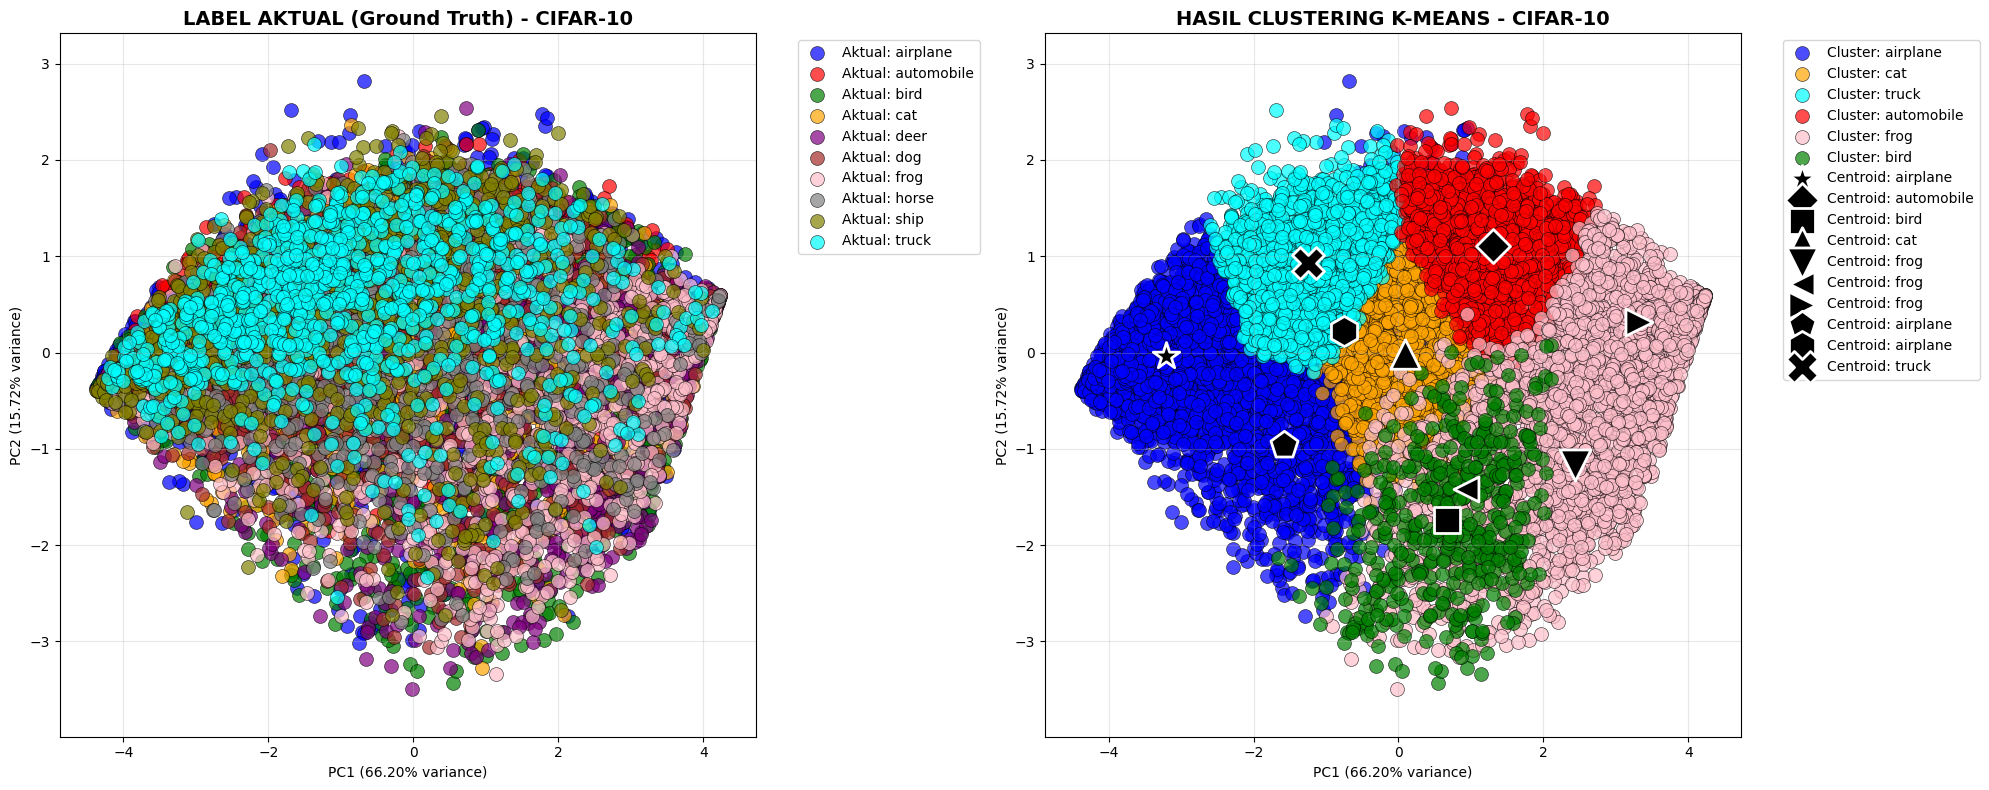


📊 Variance yang dijelaskan oleh PCA:
   PC1: 0.6620 (66.20%)
   PC2: 0.1572 (15.72%)
   Total: 0.8192 (81.92%)

8. VALIDASI KEBAIKAN KLASTER KOMPREHENSIF

VALIDASI KEBAIKAN KLASTER KOMPREHENSIF
📊 MENGHITUNG METRIK VALIDASI KLASTER...
   🔍 Metrik Internal (tanpa ground truth)...
      ✅ Silhouette Score: 0.2521
      ✅ Calinski-Harabasz Index: 3871.4815
      ✅ Davies-Bouldin Index: 1.3347
   🔍 Metrik Eksternal (dengan ground truth)...
      ✅ Adjusted Rand Index: 0.0355
      ✅ Normalized Mutual Information: 0.0734
      ✅ Homogeneity: 0.0721
      ✅ Completeness: 0.0748
      ✅ V-Measure: 0.0734
   🔍 Statistik Dasar Klaster...
      ✅ Jumlah klaster: 10
      ✅ Ukuran klaster: min=455, max=1647, std=403.97
📈 MEMBUAT VISUALISASI HASIL VALIDASI...
💾 Plot validasi disimpan ke: C:/Users/Ahsan/Downloads/data/archive\validasi_klaster_visualisasi.png


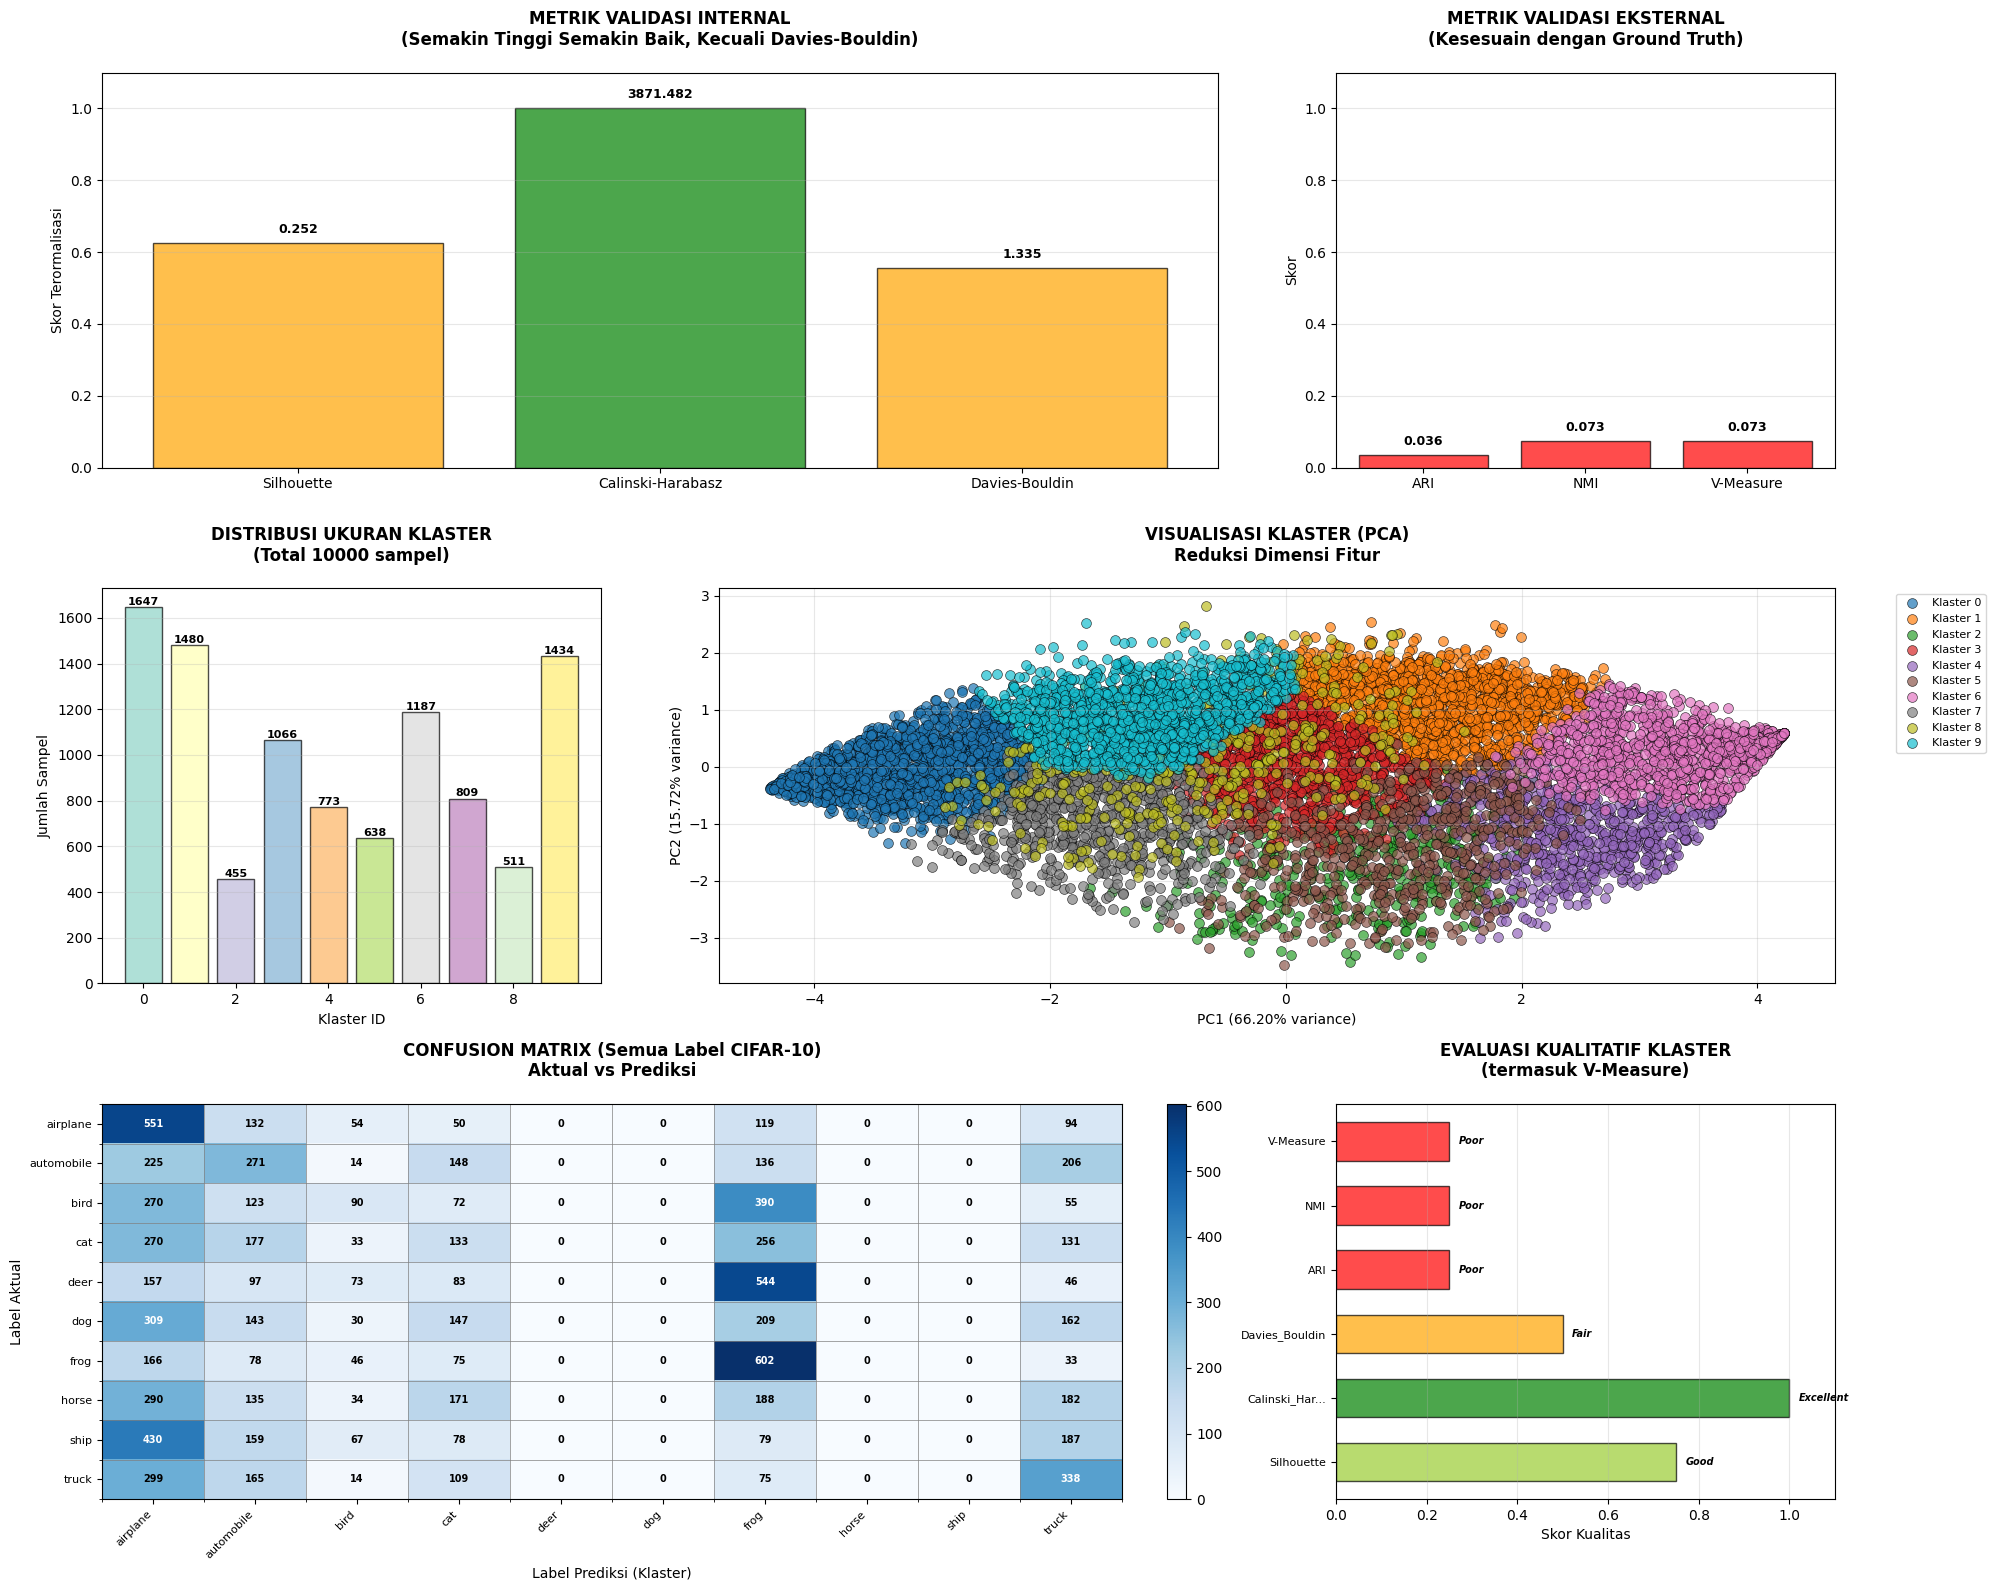

📋 MEMBUAT LAPORAN CLUSTERING...


c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\envs\cifar10\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


💾 Laporan validasi disimpan ke: C:/Users/Ahsan/Downloads/data/archive\laporan_validasi_klaster.xlsx

📊 RINGKASAN VALIDASI KLASTER:
   ✅ Jumlah klaster: 10
   ✅ Total sampel: 10000
   ✅ Silhouette Score: 0.2521 (Fair (Klaster perlu perbaikan))
   ✅ Adjusted Rand Index: 0.0355 (Poor (Kesepakatan lemah))
   ✅ Keseimbangan klaster: N/A

9. MENYIMPAN HASIL CLUSTERING TESTING: C:/Users/Ahsan/Downloads/data/archive\cifar10_hasil_clustering_10kelas.xlsx
💾 Hasil clustering disimpan ke: C:/Users/Ahsan/Downloads/data/archive\cifar10_hasil_clustering_10kelas.xlsx

🎉 PROSES TESTING SELESAI UNTUK 10 KELAS CIFAR-10!

📊 RINGKASAN HASIL TESTING:
   - Total gambar testing diproses: 10000
   - Akurasi clustering: 19.85%
   - Silhouette Score: 0.2521
   - Adjusted Rand Index: 0.0355
   - File output:
     * Data RGB Training: C:/Users/Ahsan/Downloads/data/archive\cifar10_data_ekstraksi_rgb_10kelas.xlsx
     * Data ECDF Training (CSV): C:/Users/Ahsan/Downloads/data/archive\cifar10_data_ecdf_rgb_10kelas.csv

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pickle

# =============================================
# KONFIGURASI - CIFAR-10 DATASET (PATH DIESKSPOR KE DOWNLOADS/ARCHIVE)
# =============================================
base_path = "C:/Users/Ahsan/Downloads/data/archive"
cifar10_train_folder = os.path.join(base_path, "cifar10_train")
cifar10_test_folder = os.path.join(base_path, "cifar10_test")

# 10 kelas CIFAR-10
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# File output dengan path yang sesuai
output_excel = os.path.join(base_path, "cifar10_data_ekstraksi_rgb_10kelas.xlsx")
ecdf_output_csv = os.path.join(base_path, "cifar10_data_ecdf_rgb_10kelas.csv")
ecdf_intensity_output_excel = os.path.join(base_path, "cifar10_data_ecdf_intensitas_10kelas.xlsx")
conversion_output_excel = os.path.join(base_path, "cifar10_data_ecdf_cdf_konversi_10kelas.xlsx")
clustering_output_excel = os.path.join(base_path, "cifar10_hasil_clustering_10kelas.xlsx")
centroid_output_file = os.path.join(base_path, "cifar10_centroid_10kelas.pkl")
validation_output_excel = os.path.join(base_path, "cifar10_validasi_klaster_10kelas.xlsx")

p = 16  # Ukuran resize gambar: p x p (sesuai CIFAR-10 asli)

# =============================================
# FUNGSI VALIDASI KEBENARAN KLASTER
# =============================================

def calculate_comprehensive_cluster_validation(X, cluster_labels, true_labels=None):
    """
    Menghitung berbagai metrik validasi klaster secara komprehensif
    """
    validation_results = {}
    
    print("📊 MENGHITUNG METRIK VALIDASI KLASTER...")
    
    # ==================== METRIK INTERNAL (tanpa ground truth) ====================
    print("   🔍 Metrik Internal (tanpa ground truth)...")
    
    try:
        # 1. Silhouette Score
        validation_results['Silhouette_Score'] = silhouette_score(X, cluster_labels)
        print(f"      ✅ Silhouette Score: {validation_results['Silhouette_Score']:.4f}")
    except Exception as e:
        validation_results['Silhouette_Score'] = None
        print(f"      ❌ Silhouette Score gagal: {e}")
    
    try:
        # 2. Calinski-Harabasz Index
        validation_results['Calinski_Harabasz_Index'] = calinski_harabasz_score(X, cluster_labels)
        print(f"      ✅ Calinski-Harabasz Index: {validation_results['Calinski_Harabasz_Index']:.4f}")
    except Exception as e:
        validation_results['Calinski_Harabasz_Index'] = None
        print(f"      ❌ Calinski-Harabasz Index gagal: {e}")
    
    try:
        # 3. Davies-Bouldin Index
        validation_results['Davies_Bouldin_Index'] = davies_bouldin_score(X, cluster_labels)
        print(f"      ✅ Davies-Bouldin Index: {validation_results['Davies_Bouldin_Index']:.4f}")
    except Exception as e:
        validation_results['Davies_Bouldin_Index'] = None
        print(f"      ❌ Davies-Bouldin Index gagal: {e}")
    
    # ==================== METRIK EKSTERNAL (dengan ground truth) ====================
    if true_labels is not None:
        print("   🔍 Metrik Eksternal (dengan ground truth)...")
        
        try:
            # 4. Adjusted Rand Index (ARI)
            validation_results['Adjusted_Rand_Index'] = adjusted_rand_score(true_labels, cluster_labels)
            print(f"      ✅ Adjusted Rand Index: {validation_results['Adjusted_Rand_Index']:.4f}")
        except Exception as e:
            validation_results['Adjusted_Rand_Index'] = None
            print(f"      ❌ Adjusted Rand Index gagal: {e}")
        
        try:
            # 5. Normalized Mutual Information (NMI)
            validation_results['Normalized_Mutual_Info'] = normalized_mutual_info_score(true_labels, cluster_labels)
            print(f"      ✅ Normalized Mutual Information: {validation_results['Normalized_Mutual_Info']:.4f}")
        except Exception as e:
            validation_results['Normalized_Mutual_Info'] = None
            print(f"      ❌ Normalized Mutual Information gagal: {e}")
        
        try:
            # 6. Homogeneity, Completeness, V-measure
            validation_results['Homogeneity_Score'] = homogeneity_score(true_labels, cluster_labels)
            validation_results['Completeness_Score'] = completeness_score(true_labels, cluster_labels)
            validation_results['V_Measure_Score'] = v_measure_score(true_labels, cluster_labels)
            print(f"      ✅ Homogeneity: {validation_results['Homogeneity_Score']:.4f}")
            print(f"      ✅ Completeness: {validation_results['Completeness_Score']:.4f}")
            print(f"      ✅ V-Measure: {validation_results['V_Measure_Score']:.4f}")
        except Exception as e:
            validation_results['Homogeneity_Score'] = None
            validation_results['Completeness_Score'] = None
            validation_results['V_Measure_Score'] = None
            print(f"      ❌ Homogeneity/Completeness/V-measure gagal: {e}")
    
    # ==================== STATISTIK DASAR KLASTER ====================
    print("   🔍 Statistik Dasar Klaster...")
    
    n_clusters = len(np.unique(cluster_labels))
    n_samples = len(cluster_labels)
    
    validation_results['Number_of_Clusters'] = n_clusters
    validation_results['Number_of_Samples'] = n_samples
    validation_results['Samples_per_Cluster_Avg'] = n_samples / n_clusters if n_clusters > 0 else 0
    
    # Hitung ukuran setiap klaster
    cluster_sizes = [np.sum(cluster_labels == i) for i in range(n_clusters)]
    validation_results['Cluster_Sizes'] = cluster_sizes
    validation_results['Smallest_Cluster_Size'] = min(cluster_sizes) if cluster_sizes else 0
    validation_results['Largest_Cluster_Size'] = max(cluster_sizes) if cluster_sizes else 0
    validation_results['Cluster_Size_Std'] = np.std(cluster_sizes) if cluster_sizes else 0
    
    print(f"      ✅ Jumlah klaster: {n_clusters}")
    print(f"      ✅ Ukuran klaster: min={min(cluster_sizes)}, max={max(cluster_sizes)}, std={np.std(cluster_sizes):.2f}")
    
    return validation_results

def interpret_validation_metrics(validation_results):
    """
    Memberikan interpretasi kualitatif dari metrik validasi
    """
    interpretation = {}
    
    # Interpretasi Silhouette Score
    if validation_results.get('Silhouette_Score') is not None:
        sil_score = validation_results['Silhouette_Score']
        if sil_score > 0.7:
            interpretation['Silhouette'] = "Excellent (Struktur klaster sangat kuat)"
        elif sil_score > 0.5:
            interpretation['Silhouette'] = "Good (Struktur klaster baik)"
        elif sil_score > 0.25:
            interpretation['Silhouette'] = "Fair (Klaster perlu perbaikan)"
        else:
            interpretation['Silhouette'] = "Poor (Struktur klaster lemah)"
    
    # Interpretasi Calinski-Harabasz
    if validation_results.get('Calinski_Harabasz_Index') is not None:
        ch_score = validation_results['Calinski_Harabasz_Index']
        if ch_score > 300:
            interpretation['Calinski_Harabasz'] = "Excellent (Pemisahan klaster sangat baik)"
        elif ch_score > 200:
            interpretation['Calinski_Harabasz'] = "Good (Pemisahan klaster baik)"
        elif ch_score > 100:
            interpretation['Calinski_Harabasz'] = "Fair (Pemisahan cukup)"
        else:
            interpretation['Calinski_Harabasz'] = "Poor (Pemisahan lemah)"
    
    # Interpretasi Davies-Bouldin
    if validation_results.get('Davies_Bouldin_Index') is not None:
        db_score = validation_results['Davies_Bouldin_Index']
        if db_score < 0.5:
            interpretation['Davies_Bouldin'] = "Excellent (Klaster sangat kompak dan terpisah)"
        elif db_score < 1.0:
            interpretation['Davies_Bouldin'] = "Good (Klaster kompak dan terpisah)"
        elif db_score < 1.5:
            interpretation['Davies_Bouldin'] = "Fair (Klaster cukup kompak)"
        else:
            interpretation['Davies_Bouldin'] = "Poor (Klaster tumpang tindih)"
    
    # Interpretasi metrik eksternal
    if validation_results.get('Adjusted_Rand_Index') is not None:
        ari_score = validation_results['Adjusted_Rand_Index']
        if ari_score > 0.8:
            interpretation['ARI'] = "Excellent (Kesepakatan sempurna dengan ground truth)"
        elif ari_score > 0.6:
            interpretation['ARI'] = "Good (Kesepakatan baik dengan ground truth)"
        elif ari_score > 0.4:
            interpretation['ARI'] = "Fair (Kesepakatan cukup)"
        else:
            interpretation['ARI'] = "Poor (Kesepakatan lemah)"
    
    if validation_results.get('Normalized_Mutual_Info') is not None:
        nmi_score = validation_results['Normalized_Mutual_Info']
        if nmi_score > 0.8:
            interpretation['NMI'] = "Excellent (Informasi bersama sempurna)"
        elif nmi_score > 0.6:
            interpretation['NMI'] = "Good (Informasi bersama baik)"
        elif nmi_score > 0.4:
            interpretation['NMI'] = "Fair (Informasi bersama cukup)"
        else:
            interpretation['NMI'] = "Poor (Informasi bersama lemah)"
    
    # Interpretasi V-Measure (PENTING: ditambahkan)
    if validation_results.get('V_Measure_Score') is not None:
        v_score = validation_results['V_Measure_Score']
        if v_score > 0.8:
            interpretation['V_Measure'] = "Excellent (Kesesuaian sempurna antara klaster dan kelas)"
        elif v_score > 0.6:
            interpretation['V_Measure'] = "Good (Kesesuaian baik antara klaster dan kelas)"
        elif v_score > 0.4:
            interpretation['V_Measure'] = "Fair (Kesesuaian cukup)"
        else:
            interpretation['V_Measure'] = "Poor (Kesesuaian lemah)"
    
    # HAPUS atau KOMENTARI bagian Cluster Balance karena diminta untuk diganti dengan V-Measure
    # size_std = validation_results.get('Cluster_Size_Std', 0)
    # avg_size = validation_results.get('Samples_per_Cluster_Avg', 1)
    # cv_size = size_std / avg_size if avg_size > 0 else 0
    
    # if cv_size < 0.3:
    #     interpretation['Cluster_Balance'] = "Well Balanced (Klaster seimbang)"
    # elif cv_size < 0.6:
    #     interpretation['Cluster_Balance'] = "Moderately Balanced (Klaster cukup seimbang)"
    # else:
    #     interpretation['Cluster_Balance'] = "Poorly Balanced (Klaster tidak seimbang)"
    
    return interpretation

# ==================== MODIFIKASI PLOT 5: HEATMAP CONFUSION MATRIX ====================
def plot_comprehensive_validation_results(validation_results, interpretation, df_features, save_path=None):
    """
    Membuat visualisasi komprehensif untuk hasil validasi klaster
    """
    print("📈 MEMBUAT VISUALISASI HASIL VALIDASI...")
    
    # Buat figure dengan multiple subplots
    fig = plt.figure(figsize=(20, 16))
    
    # ==================== PLOT 1: METRIK INTERNAL ====================
    ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=2)
    
    internal_metrics = {
        'Silhouette': validation_results.get('Silhouette_Score'),
        'Calinski-Harabasz': validation_results.get('Calinski_Harabasz_Index'),
        'Davies-Bouldin': validation_results.get('Davies_Bouldin_Index')
    }
    
    # Normalisasi untuk plotting yang lebih baik
    normalized_internal = {}
    colors_internal = []
    
    for name, value in internal_metrics.items():
        if value is not None:
            if name == 'Silhouette':
                # Convert -1 to 1 -> 0 to 1
                normalized_internal[name] = (value + 1) / 2
                colors_internal.append('green' if value > 0.5 else 'orange' if value > 0.25 else 'red')
            elif name == 'Calinski-Harabasz':
                # Normalisasi dengan nilai maksimum yang wajar
                normalized_internal[name] = min(value / 500, 1.0) if value > 0 else 0
                colors_internal.append('green' if value > 200 else 'orange' if value > 100 else 'red')
            elif name == 'Davies-Bouldin':
                # Invers karena semakin kecil semakin baik
                normalized_internal[name] = 1 - min(value / 3, 1.0) if value > 0 else 0
                colors_internal.append('green' if value < 1.0 else 'orange' if value < 1.5 else 'red')
    
    if normalized_internal:
        names = list(normalized_internal.keys())
        values = list(normalized_internal.values())
        original_values = list(internal_metrics.values())
        
        bars = ax1.bar(names, values, color=colors_internal, alpha=0.7, edgecolor='black')
        ax1.set_title('METRIK VALIDASI INTERNAL\n(Semakin Tinggi Semakin Baik, Kecuali Davies-Bouldin)', 
                     fontsize=12, fontweight='bold', pad=20)
        ax1.set_ylabel('Skor Terormalisasi', fontsize=10)
        ax1.set_ylim(0, 1.1)
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Tambahkan nilai asli di atas bar
        for bar, norm_val, orig_val in zip(bars, values, original_values):
            if orig_val is not None:
                ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                        f'{orig_val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # ==================== PLOT 2: METRIK EKSTERNAL ====================
    ax2 = plt.subplot2grid((3, 3), (0, 2))
    
    # TAMBAHKAN V-MEASURE DI SINI
    external_metrics = {
        'ARI': validation_results.get('Adjusted_Rand_Index'),
        'NMI': validation_results.get('Normalized_Mutual_Info'),
        'V-Measure': validation_results.get('V_Measure_Score')  # V-Measure ditambahkan
    }
    
    external_metrics = {k: v for k, v in external_metrics.items() if v is not None}
    
    if external_metrics:
        names = list(external_metrics.keys())
        values = list(external_metrics.values())
        colors_external = ['green' if v > 0.6 else 'orange' if v > 0.4 else 'red' for v in values]
        
        bars = ax2.bar(names, values, color=colors_external, alpha=0.7, edgecolor='black')
        ax2.set_title('METRIK VALIDASI EKSTERNAL\n(Kesesuain dengan Ground Truth)', 
                     fontsize=12, fontweight='bold', pad=20)
        ax2.set_ylabel('Skor', fontsize=10)
        ax2.set_ylim(0, 1.1)
        ax2.grid(True, alpha=0.3, axis='y')
        
        for bar, value in zip(bars, values):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    f'{value:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # ==================== PLOT 3: DISTRIBUSI UKURAN KLASTER ====================
    ax3 = plt.subplot2grid((3, 3), (1, 0))
    
    cluster_sizes = validation_results.get('Cluster_Sizes', [])
    if cluster_sizes:
        n_clusters = len(cluster_sizes)
        colors_cluster = plt.cm.Set3(np.linspace(0, 1, n_clusters))
        
        bars = ax3.bar(range(n_clusters), cluster_sizes, color=colors_cluster, alpha=0.7, edgecolor='black')
        ax3.set_title(f'DISTRIBUSI UKURAN KLASTER\n(Total {validation_results["Number_of_Samples"]} sampel)', 
                     fontsize=12, fontweight='bold', pad=20)
        ax3.set_xlabel('Klaster ID', fontsize=10)
        ax3.set_ylabel('Jumlah Sampel', fontsize=10)
        ax3.grid(True, alpha=0.3, axis='y')
        
        # Tambahkan nilai di atas bar
        for bar, size in zip(bars, cluster_sizes):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    f'{size}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # ==================== PLOT 4: SCATTER PLOT KLASTER (PCA) ====================
    ax4 = plt.subplot2grid((3, 3), (1, 1), colspan=2)
    
    try:
        # Reduksi dimensi dengan PCA untuk visualisasi
        feature_columns = [col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label', 'cluster', 'cluster_label', 'distance_to_centroid']]
        X = df_features[feature_columns].values
        
        if len(X) > 0:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(X_scaled)
            
            # Plot berdasarkan klaster
            cluster_labels = df_features['cluster'].values
            unique_clusters = np.unique(cluster_labels)
            colors = plt.cm.tab10(np.linspace(0, 1, len(unique_clusters)))
            
            for i, cluster_id in enumerate(unique_clusters):
                mask = cluster_labels == cluster_id
                ax4.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                           c=[colors[i]], label=f'Klaster {cluster_id}', 
                           s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
            
            ax4.set_title('VISUALISASI KLASTER (PCA)\nReduksi Dimensi Fitur', 
                         fontsize=12, fontweight='bold', pad=20)
            ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=10)
            ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=10)
            ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
            ax4.grid(True, alpha=0.3)
    except Exception as e:
        ax4.text(0.5, 0.5, f'Visualisasi PCA gagal:\n{e}', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=10)
        ax4.set_title('VISUALISASI KLASTER (PCA) - GAGAL', fontsize=12, fontweight='bold')
    
    # ==================== PLOT 5: HEATMAP CONFUSION MATRIX ====================
    ax5 = plt.subplot2grid((3, 3), (2, 0), colspan=2)
    
    try:
        if 'label' in df_features.columns and 'cluster_label' in df_features.columns:
            # MODIFIKASI: Gunakan semua label CIFAR-10 untuk memastikan semua label muncul
            all_labels = cifar10_classes  # Menggunakan daftar lengkap 10 kelas CIFAR-10
            
            # Buat confusion matrix dengan semua label
            cm = confusion_matrix(
                df_features['label'], 
                df_features['cluster_label'],
                labels=all_labels
            )
            
            # Plot heatmap
            im = ax5.imshow(cm, cmap='Blues', aspect='auto')
            
            # Atur ticks dan labels untuk semua label
            ax5.set_xticks(range(len(all_labels)))
            ax5.set_yticks(range(len(all_labels)))
            ax5.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)
            ax5.set_yticklabels(all_labels, fontsize=8)
            
            ax5.set_title('CONFUSION MATRIX (Semua Label CIFAR-10)\nAktual vs Prediksi', 
                         fontsize=12, fontweight='bold', pad=20)
            ax5.set_xlabel('Label Prediksi (Klaster)', fontsize=10)
            ax5.set_ylabel('Label Aktual', fontsize=10)
            
            # Tambahkan nilai dalam heatmap
            for i in range(len(all_labels)):
                for j in range(len(all_labels)):
                    # Tentukan warna teks berdasarkan nilai sel
                    cell_value = cm[i, j]
                    max_val = cm.max() if cm.max() > 0 else 1
                    text_color = 'white' if cell_value > max_val/2 else 'black'
                    
                    ax5.text(j, i, f'{cell_value}', 
                            ha='center', va='center', 
                            color=text_color,
                            fontsize=7, fontweight='bold')
            
            # Tambahkan colorbar
            plt.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)
            
            # Tambahkan grid untuk memisahkan sel
            ax5.set_xticks(np.arange(-0.5, len(all_labels), 1), minor=True)
            ax5.set_yticks(np.arange(-0.5, len(all_labels), 1), minor=True)
            ax5.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
            
    except Exception as e:
        ax5.text(0.5, 0.5, f'Confusion Matrix gagal:\n{e}', 
                ha='center', va='center', transform=ax5.transAxes, fontsize=10)
        ax5.set_title('CONFUSION MATRIX - GAGAL', fontsize=12, fontweight='bold')
    
    # ==================== PLOT 6: INTERPRETASI KUALITATIF (DENGAN V-MEASURE) ====================
    ax6 = plt.subplot2grid((3, 3), (2, 2))
    
    if interpretation:
        # MODIFIKASI: Hapus Cluster_Balance dan tambahkan V_Measure
        filtered_interpretation = {}
        
        for aspect, quality in interpretation.items():
            # Hapus Cluster_Balance dari visualisasi
            if 'Cluster_Balance' not in aspect:
                # Ubah nama V_Measure jika ada
                if aspect == 'V_Measure':
                    filtered_interpretation['V-Measure'] = quality
                else:
                    filtered_interpretation[aspect] = quality
        
        # Tambahkan V-Measure jika ada di validation_results tapi belum di interpretation
        if 'V_Measure_Score' in validation_results and validation_results['V_Measure_Score'] is not None:
            v_score = validation_results['V_Measure_Score']
            if v_score > 0.8:
                filtered_interpretation['V-Measure'] = "Excellent (Kesesuaian sempurna antara klaster dan kelas)"
            elif v_score > 0.6:
                filtered_interpretation['V-Measure'] = "Good (Kesesuaian baik antara klaster dan kelas)"
            elif v_score > 0.4:
                filtered_interpretation['V-Measure'] = "Fair (Kesesuaian cukup)"
            else:
                filtered_interpretation['V-Measure'] = "Poor (Kesesuaian lemah)"
        
        if filtered_interpretation:
            aspects = list(filtered_interpretation.keys())
            n_aspects = len(aspects)
            
            # Konversi kualitas ke skor numerik
            quality_scores = []
            quality_labels = []
            
            for aspect in aspects:
                quality = filtered_interpretation[aspect]
                if 'Excellent' in quality or 'sempurna' in quality:
                    quality_scores.append(1.0)
                    quality_labels.append('Excellent')
                elif 'Good' in quality or 'baik' in quality:
                    quality_scores.append(0.75)
                    quality_labels.append('Good')
                elif 'Fair' in quality or 'cukup' in quality:
                    quality_scores.append(0.5)
                    quality_labels.append('Fair')
                else:
                    quality_scores.append(0.25)
                    quality_labels.append('Poor')
            
            # Buat plot bar horizontal
            y_pos = range(len(aspects))
            colors_qual = ['green' if score >= 0.8 else 'yellowgreen' if score >= 0.6 else 
                          'orange' if score >= 0.4 else 'red' for score in quality_scores]
            
            bars = ax6.barh(y_pos, quality_scores, color=colors_qual, alpha=0.7, edgecolor='black', height=0.6)
            ax6.set_yticks(y_pos)
            
            # Format label dengan wrap teks
            wrapped_labels = []
            for label in aspects:
                if len(label) > 15:
                    wrapped_labels.append(label[:12] + '...')
                else:
                    wrapped_labels.append(label)
            
            ax6.set_yticklabels(wrapped_labels, fontsize=8)
            ax6.set_xlim(0, 1.1)
            ax6.set_xlabel('Skor Kualitas', fontsize=10)
            ax6.set_title('EVALUASI KUALITATIF KLASTER\n(termasuk V-Measure)', 
                         fontsize=12, fontweight='bold', pad=20)
            ax6.grid(True, alpha=0.3, axis='x')
            
            # Tambahkan nilai kualitas di sebelah kanan
            for i, (bar, quality_label) in enumerate(zip(bars, quality_labels)):
                ax6.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                        quality_label, 
                        va='center', fontsize=7, fontweight='bold', style='italic')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Plot validasi disimpan ke: {save_path}")
    
    plt.show()

def generate_clustering_report(df_features, validation_results, interpretation, output_path):
    """
    Menghasilkan laporan clustering yang komprehensif
    """
    print("📋 MEMBUAT LAPORAN CLUSTERING...")
    
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Ringkasan Metrik
        summary_data = []
        for metric, value in validation_results.items():
            if metric != 'Cluster_Sizes' and value is not None:
                if isinstance(value, (int, float)):
                    summary_data.append({
                        'Metrik': metric,
                        'Nilai': value,
                        'Deskripsi': get_metric_description(metric)
                    })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Ringkasan_Metrik', index=False)
        
        # Sheet 2: Interpretasi Kualitatif
        interpretation_data = []
        for aspect, quality in interpretation.items():
            interpretation_data.append({
                'Aspek': aspect,
                'Kualitas': quality,
                'Rekomendasi': get_recommendation(aspect, quality)
            })
        
        df_interpretation = pd.DataFrame(interpretation_data)
        df_interpretation.to_excel(writer, sheet_name='Interpretasi_Kualitatif', index=False)
        
        # Sheet 3: Statistik Klaster
        cluster_stats = []
        cluster_sizes = validation_results.get('Cluster_Sizes', [])
        for i, size in enumerate(cluster_sizes):
            cluster_stats.append({
                'Klaster_ID': i,
                'Jumlah_Sampel': size,
                'Persentase': (size / validation_results['Number_of_Samples']) * 100 if validation_results['Number_of_Samples'] > 0 else 0
            })
        
        df_cluster_stats = pd.DataFrame(cluster_stats)
        df_cluster_stats.to_excel(writer, sheet_name='Statistik_Klaster', index=False)
        
        # Sheet 4: Detail Hasil Clustering
        df_features.to_excel(writer, sheet_name='Detail_Clustering', index=False)
        
        # Sheet 5: Classification Report (jika ada ground truth)
        if 'label' in df_features.columns and 'cluster_label' in df_features.columns:
            try:
                # Buat classification report
                report = classification_report(df_features['label'], df_features['cluster_label'], output_dict=True)
                df_report = pd.DataFrame(report).transpose()
                df_report.to_excel(writer, sheet_name='Classification_Report')
            except Exception as e:
                print(f"⚠️  Classification Report gagal: {e}")
    
    print(f"💾 Laporan validasi disimpan ke: {output_path}")

def get_metric_description(metric_name):
    """Mendapatkan deskripsi untuk setiap metrik"""
    descriptions = {
        'Silhouette_Score': 'Mengukur kohesi dan pemisahan klaster. Range: -1 (buruk) sampai 1 (bagus)',
        'Calinski_Harabasz_Index': 'Rasio variance antara klaster dan dalam klaster. Semakin tinggi semakin bagus',
        'Davies_Bouldin_Index': 'Mengukur rata-rata similarity antar klaster. Semakin rendah semakin bagus',
        'Adjusted_Rand_Index': 'Kesepakatan antara clustering dan ground truth. Range: -1 sampai 1',
        'Normalized_Mutual_Info': 'Informasi bersama yang dinormalisasi antara clustering dan ground truth. Range: 0-1',
        'Homogeneity_Score': 'Setiap klaster hanya berisi anggota dari satu kelas',
        'Completeness_Score': 'Semua anggota dari sebuah kelas ditugaskan ke klaster yang sama',
        'V_Measure_Score': 'Rata-rata harmonis dari Homogeneity dan Completeness',
        'Number_of_Clusters': 'Jumlah total klaster yang terbentuk',
        'Number_of_Samples': 'Jumlah total sampel data',
        'Samples_per_Cluster_Avg': 'Rata-rata jumlah sampel per klaster',
        'Smallest_Cluster_Size': 'Ukuran klaster terkecil',
        'Largest_Cluster_Size': 'Ukuran klaster terbesar',
        'Cluster_Size_Std': 'Standar deviasi ukuran klaster (mengukur keseimbangan)'
    }
    return descriptions.get(metric_name, 'Tidak ada deskripsi tersedia')

def get_recommendation(aspect, quality):
    """Memberikan rekomendasi berdasarkan kualitas"""
    recommendations = {
        'Silhouette': {
            'Excellent': 'Pertahankan parameter clustering saat ini',
            'Good': 'Pertimbangkan fine-tuning minor pada parameter',
            'Fair': 'Coba algoritma atau parameter clustering berbeda',
            'Poor': 'Pertimbangkan pendekatan clustering yang sama sekali berbeda'
        },
        'Calinski_Harabasz': {
            'Excellent': 'Pemisahan klaster optimal, pertahankan konfigurasi',
            'Good': 'Pemisahan baik, ada ruang untuk improvement kecil',
            'Fair': 'Coba tingkatkan pemisahan dengan feature engineering',
            'Poor': 'Pemisahan lemah, pertimbangkan reduksi dimensi'
        },
        'Davies_Bouldin': {
            'Excellent': 'Klaster sangat kompak, hasil optimal',
            'Good': 'Klaster kompak, pertahankan pendekatan',
            'Fair': 'Beberapa klaster mungkin tumpang tindih',
            'Poor': 'Klaster sangat tumpang tindih, pertimbangkan DBSCAN'
        },
        'ARI': {
            'Excellent': 'Kesepakatan sempurna dengan ground truth',
            'Good': 'Kesepakatan baik dengan ground truth',
            'Fair': 'Kesepakatan cukup, ada ruang improvement',
            'Poor': 'Kesepakatan lemah, evaluasi preprocessing'
        },
        'NMI': {
            'Excellent': 'Informasi bersama sempurna',
            'Good': 'Informasi bersama baik',
            'Fair': 'Informasi bersama cukup',
            'Poor': 'Informasi bersama lemah'
        },
        'V_Measure': {
            'Excellent': 'Harmoni antara homogeneity dan completeness sempurna',
            'Good': 'Harmoni antara homogeneity dan completeness baik',
            'Fair': 'Harmoni antara homogeneity dan completeness cukup',
            'Poor': 'Harmoni antara homogeneity dan completeness lemah'
        }
    }
    return recommendations.get(aspect, {}).get(quality.split('(')[0].strip(), 'Tidak ada rekomendasi spesifik')

def perform_comprehensive_validation(df_features, feature_columns, output_dir):
    """
    Melakukan validasi komprehensif untuk hasil clustering
    """
    print("\n" + "="*80)
    print("VALIDASI KEBAIKAN KLASTER KOMPREHENSIF")
    print("="*80)
    
    # Siapkan data untuk validasi
    X = df_features[feature_columns].values
    cluster_labels = df_features['cluster'].values
    true_labels = df_features['label'].values if 'label' in df_features.columns else None
    
    # Hitung metrik validasi
    validation_results = calculate_comprehensive_cluster_validation(X, cluster_labels, true_labels)
    
    # Interpretasi hasil
    interpretation = interpret_validation_metrics(validation_results)
    
    # Buat visualisasi
    plot_path = os.path.join(output_dir, "validasi_klaster_visualisasi.png")
    plot_comprehensive_validation_results(validation_results, interpretation, df_features, plot_path)
    
    # Buat laporan
    report_path = os.path.join(output_dir, "laporan_validasi_klaster.xlsx")
    generate_clustering_report(df_features, validation_results, interpretation, report_path)
    
    # Tampilkan ringkasan
    print("\n📊 RINGKASAN VALIDASI KLASTER:")
    print(f"   ✅ Jumlah klaster: {validation_results['Number_of_Clusters']}")
    print(f"   ✅ Total sampel: {validation_results['Number_of_Samples']}")
    
    if validation_results.get('Silhouette_Score') is not None:
        print(f"   ✅ Silhouette Score: {validation_results['Silhouette_Score']:.4f} ({interpretation.get('Silhouette', 'N/A')})")
    
    if validation_results.get('Adjusted_Rand_Index') is not None:
        print(f"   ✅ Adjusted Rand Index: {validation_results['Adjusted_Rand_Index']:.4f} ({interpretation.get('ARI', 'N/A')})")
    
    print(f"   ✅ Keseimbangan klaster: {interpretation.get('Cluster_Balance', 'N/A')}")
    
    return validation_results, interpretation

# =============================================
# FUNGSI UTAMA UNTUK MEMPROSES GAMBAR
# =============================================

def process_image(image_path, label, gambar_ke):
    """
    Memproses satu gambar: resize ke p x p, ekstrak RGB, dan simpan ke Excel
    """
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Tidak bisa membaca gambar: {image_path}")
        return None
    
    # Resize gambar menjadi p x p
    img_resized = cv2.resize(img, (p, p))
    
    # Konversi BGR ke RGB
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Ekstrak channel R, G, B
    R = img_rgb[:, :, 0].flatten()
    G = img_rgb[:, :, 1].flatten()
    B = img_rgb[:, :, 2].flatten()
    
    # Hitung statistik
    hasil = {
        'filename': os.path.basename(image_path),
        'gambar_ke': gambar_ke,
        'label': label,
        'p': p,
        'total_pixels': p * p,
        'R_values': R,
        'G_values': G,
        'B_values': B,
        'avg_R': np.mean(R),
        'avg_G': np.mean(G),
        'avg_B': np.mean(B),
        'min_R': np.min(R),
        'max_R': np.max(R),
        'min_G': np.min(G),
        'max_G': np.max(G),
        'min_B': np.min(B),
        'max_B': np.max(B)
    }
    
    return hasil

def process_all_images_from_folder(folder_path, label):
    """
    Memproses semua gambar dalam folder untuk satu kelas
    """
    results = []
    
    if not os.path.exists(folder_path):
        print(f"❌ Folder tidak ditemukan: {folder_path}")
        return pd.DataFrame()
    
    image_files = [f for f in os.listdir(folder_path) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print(f"❌ Tidak ada gambar ditemukan di: {folder_path}")
        return pd.DataFrame()
    
    print(f"📁 Memproses {len(image_files)} gambar dari {folder_path} (label: {label})")
    
    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        
        result = process_image(image_path, label, i+1)
        if result is not None:
            results.append(result)
    
    # Konversi ke DataFrame
    if results:
        df = pd.DataFrame(results)
        print(f"✅ Berhasil memproses {len(df)} gambar dengan label: {label}")
        return df
    else:
        print(f"❌ Tidak ada hasil yang berhasil diproses dari {folder_path}")
        return pd.DataFrame()

def process_cifar10_dataset(base_folder, dataset_type="train"):
    """
    Memproses semua kelas CIFAR-10 dari folder base
    """
    all_dfs = []
    
    for class_name in cifar10_classes:
        class_folder = os.path.join(base_folder, class_name)
        df_class = process_all_images_from_folder(class_folder, class_name)
        if not df_class.empty:
            all_dfs.append(df_class)
    
    if all_dfs:
        df_combined = pd.concat(all_dfs, ignore_index=True)
        print(f"✅ Total {len(df_combined)} gambar diproses dari {dataset_type} dataset")
        return df_combined
    else:
        print(f"❌ Tidak ada data yang diproses dari {dataset_type} dataset")
        return pd.DataFrame()

def save_rgb_to_excel(df_rgb, output_path):
    """
    Menyimpan data RGB ke file Excel
    """
    # Buat DataFrame yang lebih sederhana untuk disimpan
    save_data = []
    for _, row in df_rgb.iterrows():
        save_data.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label': row['label'],
            'p': row['p'],
            'total_pixels': row['total_pixels'],
            'R_values': str(row['R_values'].tolist()),
            'G_values': str(row['G_values'].tolist()),
            'B_values': str(row['B_values'].tolist()),
            'avg_R': row['avg_R'],
            'avg_G': row['avg_G'],
            'avg_B': row['avg_B'],
            'min_R': row['min_R'],
            'max_R': row['max_R'],
            'min_G': row['min_G'],
            'max_G': row['max_G'],
            'min_B': row['min_B'],
            'max_B': row['max_B']
        })
    
    df_save = pd.DataFrame(save_data)
    df_save.to_excel(output_path, index=False)
    print(f"💾 Data RGB disimpan ke: {output_path}")

# =============================================
# FUNGSI ECDF
# =============================================

def calculate_ecdf(values):
    """
    Menghitung ECDF untuk suatu set nilai
    """
    if len(values) == 0:
        return np.array([]), np.array([])
    
    # Urutkan nilai
    sorted_values = np.sort(values)
    
    # Hitung ECDF
    n = len(sorted_values)
    ecdf = np.arange(1, n + 1) / n
    
    return sorted_values, ecdf

def calculate_ecdf_for_image(image_data):
    """
    Menghitung ECDF untuk sebuah gambar
    """
    filename = image_data['filename']
    j = image_data['gambar_ke']
    label = image_data['label']
    p_j = image_data['p']
    
    ecdf_data = {
        'filename': filename,
        'gambar_ke': j,
        'label': label,
        'p_j': p_j,
        'R': {'intensity': [], 'ecdf': []},
        'G': {'intensity': [], 'ecdf': []},
        'B': {'intensity': [], 'ecdf': []}
    }
    
    # Untuk setiap channel R, G, B
    for channel in ['R', 'G', 'B']:
        values = image_data[f'{channel}_values']
        
        if len(values) > 0:
            intensity, ecdf = calculate_ecdf(values)
            ecdf_data[channel]['intensity'] = intensity
            ecdf_data[channel]['ecdf'] = ecdf
    
    return ecdf_data

def calculate_all_ecdf(df_rgb):
    """
    Menghitung ECDF untuk semua gambar
    """
    ecdf_results = {}
    
    for _, row in df_rgb.iterrows():
        ecdf_data = calculate_ecdf_for_image(row)
        ecdf_results[row['filename']] = ecdf_data
    
    return ecdf_results

def save_ecdf_to_csv(ecdf_data, output_path):
    """
    Menyimpan data ECDF ke file CSV (bukan Excel) untuk handle data besar
    """
    save_data = []
    
    for filename, data in ecdf_data.items():
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            if len(channel_data['intensity']) > 0:
                for intensity, ecdf_val in zip(channel_data['intensity'], channel_data['ecdf']):
                    save_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'intensity': intensity,
                        'ecdf': ecdf_val,
                        'p_j': data['p_j']
                    })
    
    df_save = pd.DataFrame(save_data)
    
    # Simpan ke CSV bukan Excel
    df_save.to_csv(output_path, index=False)
    print(f"💾 Data ECDF disimpan ke: {output_path}")
    print(f"📊 Jumlah baris data ECDF: {len(df_save)}")

# =============================================
# FUNGSI MODEL MATEMATIS V DAN KONVERSI CDF
# =============================================

def create_mathematical_model_V(df_cdf):
    """
    Membuat model matematis V dari data CDF intensitas
    """
    model_V = {}
    
    # Channel R: intensitas 100, 150, 200
    for intensity in [100, 150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'R') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            model_V[f'R_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Channel G: intensitas 150, 200
    for intensity in [150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'G') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            model_V[f'G_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    # Channel B: intensitas 150, 200
    for intensity in [150, 200]:
        channel_data = df_cdf[(df_cdf['channel'] == 'B') & (df_cdf['intensity_target'] == intensity)]
        if not channel_data.empty:
            model_V[f'B_{intensity}'] = {
                'ecdf_values': channel_data['ecdf_value'].values,
                'cdf_values': channel_data['cdf_value'].values
            }
    
    print("✅ Model matematis V berhasil dibuat")
    print(f"🔧 Komponen model V: {list(model_V.keys())}")
    
    return model_V

def convert_ecdf_to_cdf_with_model_V(ecdf_value, model_key, model_V):
    """
    Mengkonversi nilai ECDF ke CDF menggunakan model matematis V
    """
    if model_key not in model_V:
        return None
    
    model_data = model_V[model_key]
    ecdf_values = model_data['ecdf_values']
    cdf_values = model_data['cdf_values']
    
    # Jika ECDF value di luar range model, return None
    if ecdf_value < ecdf_values[0] or ecdf_value > ecdf_values[-1]:
        return None
    
    # Cari posisi ECDF value dalam model
    idx = np.searchsorted(ecdf_values, ecdf_value, side='right') - 1
    
    # Return CDF value yang sesuai
    return cdf_values[idx]

def extract_and_convert_ecdf_data(ecdf_data, model_V):
    """
    Mengekstrak ECDF dari gambar pada intensitas tertentu dan mengkonversinya ke CDF menggunakan model V
    """
    conversion_results = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        # Ekstrak ECDF pada intensitas tertentu untuk semua channel
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target
                for intensity in [100, 150, 200]:
                    # Tentukan model_key berdasarkan channel dan intensitas
                    model_key = f'{channel}_{intensity}'
                    
                    # Skip jika model_key tidak ada di model_V
                    if model_key not in model_V:
                        continue
                    
                    # Cari nilai ECDF pada intensitas target
                    ecdf_val = 0.0
                    for m in range(len(intensity_values)):
                        if intensity < intensity_values[0]:
                            ecdf_val = 0.0
                            break
                        elif intensity >= intensity_values[m]:
                            if m == len(intensity_values) - 1 or intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        elif intensity >= intensity_values[-1]:
                            ecdf_val = 1.0
                            break
                    
                    # Konversi ECDF ke CDF menggunakan model V
                    cdf_val = convert_ecdf_to_cdf_with_model_V(ecdf_val, model_key, model_V)
                    
                    conversion_results.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val,
                        'cdf_value': cdf_val,
                        'model_key': model_key
                    })
    
    df_conversion = pd.DataFrame(conversion_results)
    return df_conversion

def save_conversion_data(ecdf_data, df_conversion, output_path):
    """
    Menyimpan data ECDF gambar dan CDF hasil konversi ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data konversi ECDF ke CDF (data kecil)
        df_conversion.to_excel(writer, sheet_name='Konversi_ECDF_ke_CDF', index=False)
        
        # Sheet 2: Ringkasan ECDF per gambar (data lebih kecil)
        summary_data = []
        for filename, data in ecdf_data.items():
            for channel in ['R', 'G', 'B']:
                channel_data = data[channel]
                if len(channel_data['intensity']) > 0:
                    summary_data.append({
                        'filename': filename,
                        'gambar_ke': data['gambar_ke'],
                        'label': data['label'],
                        'channel': channel,
                        'num_points': len(channel_data['intensity']),
                        'min_intensity': min(channel_data['intensity']),
                        'max_intensity': max(channel_data['intensity']),
                        'min_ecdf': min(channel_data['ecdf']),
                        'max_ecdf': max(channel_data['ecdf'])
                    })
        
        df_summary = pd.DataFrame(summary_data)
        df_summary.to_excel(writer, sheet_name='Ringkasan_ECDF', index=False)
    
    print(f"💾 Data konversi CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI EKSTRAKSI ECDF PADA INTENSITAS TERTENTU
# =============================================

def extract_ecdf_at_intensities(ecdf_data, intensities=[100, 150, 200]):
    """
    Mengekstrak nilai ECDF pada intensitas tertentu untuk setiap gambar dan channel
    """
    ecdf_intensity_data = []
    
    for filename, data in ecdf_data.items():
        j = data['gambar_ke']
        label = data['label']
        
        for channel in ['R', 'G', 'B']:
            channel_data = data[channel]
            intensity_values = channel_data['intensity']
            ecdf_values = channel_data['ecdf']
            
            if len(intensity_values) > 0:
                # Untuk setiap intensitas target, cari nilai ECDF-nya
                for intensity in intensities:
                    ecdf_val = 0.0
                    
                    if intensity < intensity_values[0]:
                        ecdf_val = 0.0
                    elif intensity >= intensity_values[-1]:
                        ecdf_val = 1.0
                    else:
                        # Cari di segmen mana intensitas berada
                        for m in range(len(intensity_values) - 1):
                            if intensity_values[m] <= intensity < intensity_values[m + 1]:
                                ecdf_val = ecdf_values[m]
                                break
                        else:
                            # Jika tidak ditemukan dalam loop, gunakan nilai terakhir
                            ecdf_val = ecdf_values[-1] if intensity >= intensity_values[-1] else 0.0
                    
                    ecdf_intensity_data.append({
                        'filename': filename,
                        'gambar_ke': j,
                        'label': label,
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val
                    })
    
    df_ecdf_intensities = pd.DataFrame(ecdf_intensity_data)
    return df_ecdf_intensities

def calculate_cdf_for_ecdf_intensities(df_ecdf_intensities):
    """
    Menghitung CDF untuk nilai ECDF pada intensitas tertentu per channel
    """
    cdf_data = []
    
    for channel in ['R', 'G', 'B']:
        for intensity in [100, 150, 200]:
            # Ambil nilai ECDF untuk channel dan intensitas tertentu
            ecdf_values = df_ecdf_intensities[
                (df_ecdf_intensities['channel'] == channel) & 
                (df_ecdf_intensities['intensity_target'] == intensity)
            ]['ecdf_value'].values
            
            if len(ecdf_values) > 0:
                # Urutkan nilai ECDF
                sorted_ecdf = np.sort(ecdf_values)
                
                # Hitung CDF
                cdf_values = np.arange(1, len(sorted_ecdf) + 1) / len(sorted_ecdf)
                
                # Simpan data
                for ecdf_val, cdf_val in zip(sorted_ecdf, cdf_values):
                    cdf_data.append({
                        'channel': channel,
                        'intensity_target': intensity,
                        'ecdf_value': ecdf_val,
                        'cdf_value': cdf_val
                    })
    
    df_cdf = pd.DataFrame(cdf_data)
    return df_cdf

def save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, output_path):
    """
    Menyimpan data ECDF pada intensitas tertentu dan CDF-nya ke Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Data ECDF pada intensitas tertentu
        df_ecdf_intensities.to_excel(writer, sheet_name='ECDF_Intensitas', index=False)
        
        # Sheet 2: Data CDF dari ECDF intensitas
        df_cdf.to_excel(writer, sheet_name='CDF_ECDF_Intensitas', index=False)
    
    print(f"💾 Data ECDF intensitas dan CDF disimpan ke: {output_path}")

# =============================================
# FUNGSI CENTROID DAN CLUSTERING UNTUK 10 KELAS
# =============================================

def calculate_class_centroids(df_features):
    """
    Menghitung centroid untuk setiap kelas dengan mengambil rata-rata dari semua gambar dalam kelas tersebut
    """
    centroids = {}
    
    # Filter hanya kolom fitur (exclude metadata)
    feature_columns = [col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']]
    
    # Dapatkan label unik yang sebenarnya ada di data
    actual_labels = df_features['label'].unique()
    
    for label in actual_labels:
        class_data = df_features[df_features['label'] == label]
        if len(class_data) > 0:
            # Hitung rata-rata untuk setiap fitur
            centroid_values = class_data[feature_columns].mean(axis=0).values
            centroids[label] = centroid_values
            print(f"✅ Centroid untuk kelas '{label}': {len(class_data)} gambar")
        else:
            print(f"❌ Tidak ada gambar untuk kelas '{label}'")
    
    return centroids, feature_columns

def save_centroids(centroids, feature_columns, output_path):
    """
    Menyimpan centroid ke file pickle
    """
    centroid_data = {
        'centroids': centroids,
        'feature_columns': feature_columns
    }
    
    with open(output_path, 'wb') as f:
        pickle.dump(centroid_data, f)
    
    print(f"💾 Centroid disimpan ke: {output_path}")

def load_centroids(input_path):
    """
    Memuat centroid dari file pickle
    """
    with open(input_path, 'rb') as f:
        centroid_data = pickle.load(f)
    
    print(f"💾 Centroid dimuat dari: {input_path}")
    return centroid_data['centroids'], centroid_data['feature_columns']

def prepare_features_for_clustering(df_conversion):
    """
    Menyiapkan fitur untuk clustering dari data CDF hasil konversi
    """
    # Group by filename untuk mendapatkan semua fitur CDF per gambar
    features_data = []
    
    for filename in df_conversion['filename'].unique():
        file_data = df_conversion[df_conversion['filename'] == filename]
        
        # Ekstrak semua nilai CDF untuk gambar ini
        feature_vector = {}
        feature_vector['filename'] = filename
        feature_vector['gambar_ke'] = file_data['gambar_ke'].iloc[0]
        feature_vector['label'] = file_data['label'].iloc[0]
        
        # Untuk setiap kombinasi channel dan intensitas
        for _, row in file_data.iterrows():
            key = f"{row['channel']}_{row['intensity_target']}"
            feature_vector[key] = row['cdf_value']
        
        features_data.append(feature_vector)
    
    df_features = pd.DataFrame(features_data)
    
    # DEBUG: Tampilkan label yang unik dan jumlahnya
    print("\n🔍 DEBUG - Label unik di df_features:")
    print(df_features['label'].value_counts())
    
    # Fill NaN values dengan 0
    df_features = df_features.fillna(0)
    
    return df_features

def perform_kmeans_clustering_10centroids(df_features, centroids_dict, feature_columns):
    """
    Melakukan K-means clustering dengan 10 centroid berdasarkan CDF hasil konversi
    Centroid diinisialisasi dengan rata-rata setiap kelas
    """
    print(f"\n🔍 Menyiapkan centroid dari rata-rata masing-masing kelas")
    
    # Filter hanya kolom fitur (exclude metadata)
    if len(feature_columns) == 0:
        print("❌ Tidak ada fitur yang ditemukan untuk clustering!")
        return None, None, None, []
    
    # Ekstrak matriks fitur
    X = df_features[feature_columns].values
    
    if len(centroids_dict) < 10:
        print(f"⚠️  Hanya {len(centroids_dict)} kelas yang memiliki centroid! Menggunakan centroid acak...")
        # Fallback: gunakan K-means dengan inisialisasi random
        kmeans = KMeans(n_clusters=10, random_state=42)
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
    else:
        # Siapkan initial centroids dari rata-rata kelas
        initial_centroids = np.array(list(centroids_dict.values()))
        
        print(f"📍 Shape initial centroids: {initial_centroids.shape}")
        print(f"🎯 Kelas yang digunakan: {list(centroids_dict.keys())}")
        
        # Lakukan K-means dengan inisialisasi centroid spesifik
        kmeans = KMeans(
            n_clusters=10,
            init=initial_centroids,
            n_init=1,  # Hanya gunakan inisialisasi yang diberikan
            max_iter=300,
            random_state=42
        )
        
        labels = kmeans.fit_predict(X)
        centroids = kmeans.cluster_centers_
        
        print("✅ K-means clustering dengan centroid berhasil!")
    
    # Tambahkan hasil clustering ke DataFrame
    df_features = df_features.copy()
    df_features['cluster'] = labels
    df_features['distance_to_centroid'] = kmeans.transform(X).min(axis=1)
    
    # Mapping cluster ke label berdasarkan centroid terdekat
    cluster_mapping = {}
    
    # Untuk setiap cluster, cari centroid kelas mana yang paling dekat
    for cluster_idx in range(len(centroids_dict)):
        if cluster_idx < len(centroids):  # Pastikan cluster_idx valid
            cluster_center = centroids[cluster_idx]
            
            # Hitung jarak ke setiap centroid kelas
            distances = {}
            for label, class_centroid in centroids_dict.items():
                distance = np.linalg.norm(cluster_center - class_centroid)
                distances[label] = distance
            
            # Pilih label dengan jarak terdekat
            if distances:  # Pastikan distances tidak kosong
                closest_label = min(distances, key=distances.get)
                cluster_mapping[cluster_idx] = closest_label
    
    print(f"🔀 Mapping cluster: {cluster_mapping}")
    
    df_features['cluster_label'] = df_features['cluster'].map(cluster_mapping)
    
    # Simpan informasi centroid yang digunakan
    centroid_info = []
    for cluster_idx, label in cluster_mapping.items():
        centroid_info.append({
            'cluster': cluster_idx,
            'cluster_label': label,
            'centroid_values': centroids[cluster_idx] if cluster_idx < len(centroids) else None
        })
    
    return df_features, kmeans, feature_columns, centroid_info

def analyze_clustering_results_10classes(df_features, df_conversion, centroid_info):
    """
    Menganalisis dan menampilkan hasil clustering untuk 10 kelas
    """
    print("\n" + "="*80)
    print("HASIL K-MEANS CLUSTERING - 10 KELAS CIFAR-10")
    print("="*80)
    
    # Tampilkan informasi centroid
    print("\n🎯 INFORMASI CENTROID:")
    for i, centroid in enumerate(centroid_info):
        print(f"   Cluster {centroid['cluster']}: {centroid['cluster_label']}")
    
    # Hitung akurasi clustering
    correct_predictions = 0
    total_predictions = len(df_features)
    
    clustering_results = []
    
    for _, row in df_features.iterrows():
        actual_label = row['label']
        predicted_label = row['cluster_label']
        is_correct = (actual_label == predicted_label)
        
        if is_correct:
            correct_predictions += 1
        
        clustering_results.append({
            'filename': row['filename'],
            'gambar_ke': row['gambar_ke'],
            'label_aktual': actual_label,
            'cluster_prediksi': row['cluster'],
            'label_prediksi': predicted_label,
            'benar': is_correct,
            'jarak_ke_centroid': row['distance_to_centroid']
        })
    
    accuracy = correct_predictions / total_predictions * 100 if total_predictions > 0 else 0
    
    print(f"\n📈 AKURASI CLUSTERING: {accuracy:.2f}%")
    print(f"   Benar: {correct_predictions}/{total_predictions}")
    
    # Tampilkan confusion matrix sederhana
    print("\n📊 CONFUSION MATRIX:")
    df_results = pd.DataFrame(clustering_results)
    if not df_results.empty:
        confusion_matrix = pd.crosstab(df_results['label_aktual'], df_results['label_prediksi'])
        print(confusion_matrix)
    
    return df_results, accuracy

def plot_clustering_results_10classes(df_features, feature_columns, centroid_info):
    """
    Membuat visualisasi hasil clustering untuk 10 kelas
    """
    print("\n" + "="*80)
    print("VISUALISASI HASIL CLUSTERING - 10 KELAS CIFAR-10")
    print("="*80)
    
    # Standardisasi fitur
    X = df_features[feature_columns].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Reduksi dimensi dengan PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Hitung batas yang sama untuk kedua plot
    x_min = min(X_pca[:, 0]) - 0.5
    x_max = max(X_pca[:, 0]) + 0.5
    y_min = min(X_pca[:, 1]) - 0.5
    y_max = max(X_pca[:, 1]) + 0.5
    
    # Buat plot dengan ukuran yang lebih besar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Warna untuk plot
    colors = {
        'airplane': 'blue', 'automobile': 'red', 'bird': 'green', 'cat': 'orange', 
        'deer': 'purple', 'dog': 'brown', 'frog': 'pink', 'horse': 'gray', 
        'ship': 'olive', 'truck': 'cyan'
    }
    
    # Plot 1: Label aktual
    actual_labels = df_features['label'].unique()
    for label in actual_labels:
        mask = df_features['label'] == label
        color = colors.get(label, 'black')  # Default black jika label tidak dikenali
        if mask.any():
            ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Aktual: {label}', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    ax1.set_title('LABEL AKTUAL (Ground Truth) - CIFAR-10', fontsize=14, fontweight='bold')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)
    
    # Plot 2: Hasil clustering
    cluster_labels = df_features['cluster_label'].unique()
    for cluster_label in cluster_labels:
        mask = df_features['cluster_label'] == cluster_label
        color = colors.get(cluster_label, 'black')  # Default black jika label tidak dikenali
        if mask.any():
            ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                       c=color, label=f'Cluster: {cluster_label}', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
    
    # Tandai centroid dengan spesial marker
    print(f"🎯 Menampilkan {len(centroid_info)} centroid di plot...")
    centroid_markers = ['*', 'D', 's', '^', 'v', '<', '>', 'p', 'h', 'X']
    centroid_sizes = [400, 300, 350, 450, 500, 320, 380, 420, 470, 530]
    
    # Plot centroid (gunakan PCA transform dari centroid asli)
    for idx, centroid in enumerate(centroid_info):
        if centroid['centroid_values'] is not None:
            # Transform centroid ke ruang PCA
            centroid_scaled = scaler.transform([centroid['centroid_values']])
            centroid_pca = pca.transform(centroid_scaled)[0]
            
            marker = centroid_markers[idx % len(centroid_markers)]
            size = centroid_sizes[idx % len(centroid_sizes)]
            
            ax2.scatter(centroid_pca[0], centroid_pca[1], 
                       c='black', marker=marker, s=size,
                       label=f"Centroid: {centroid['cluster_label']}",
                       edgecolors='white', linewidth=2, zorder=5)
            
            print(f"   ✅ Centroid {idx}: {centroid['cluster_label']} di posisi {centroid_pca}")
    
    ax2.set_title('HASIL CLUSTERING K-MEANS - CIFAR-10', fontsize=14, fontweight='bold')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
    # Print variance explained oleh PCA
    print(f"\n📊 Variance yang dijelaskan oleh PCA:")
    print(f"   PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]:.2%})")
    print(f"   PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]:.2%})")
    print(f"   Total: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_):.2%})")

def save_clustering_results(df_features, df_results, accuracy, output_path):
    """
    Menyimpan hasil clustering ke file Excel
    """
    with pd.ExcelWriter(output_path) as writer:
        # Sheet 1: Fitur dan hasil clustering
        df_features.to_excel(writer, sheet_name='Fitur_dan_Clustering', index=False)
        
        # Sheet 2: Ringkasan hasil
        df_results.to_excel(writer, sheet_name='Hasil_Clustering', index=False)
        
        # Sheet 3: Statistik clustering
        accuracy_data = [{
            'total_gambar': len(df_features),
            'benar': len(df_results[df_results['benar'] == True]),
            'salah': len(df_results[df_results['benar'] == False]),
            'akurasi': accuracy
        }]
        df_accuracy = pd.DataFrame(accuracy_data)
        df_accuracy.to_excel(writer, sheet_name='Statistik', index=False)
    
    print(f"💾 Hasil clustering disimpan ke: {output_path}")

# =============================================
# FUNGSI UTAMA UNTUK CIFAR-10 DENGAN VALIDASI
# =============================================

def main_cifar10_training():
    """
    Fungsi utama untuk memproses data training CIFAR-10 (10 kelas)
    """
    print("PROSES EKSTRAKSI RGB, ECDF, DAN ANALISIS INTENSITAS - 10 KELAS CIFAR-10 (TRAINING)")
    print("=" * 80)
    
    # 1. Proses gambar training dari 10 kelas CIFAR-10
    print("\n1. PROSES GAMBAR TRAINING DARI 10 KELAS CIFAR-10")
    df_train = process_cifar10_dataset(cifar10_train_folder, "training")
    
    if df_train.empty:
        print("❌ Tidak ada data training yang diproses. Periksa path folder dan file gambar.")
        return None, None
    
    print(f"\n📊 Total gambar training diproses: {len(df_train)}")
    for class_name in cifar10_classes:
        count = len(df_train[df_train['label'] == class_name])
        print(f"  - {class_name}: {count} gambar")
    
    # 2. Simpan data RGB training ke Excel
    print(f"\n2. MENYIMPAN DATA RGB TRAINING KE EXCEL: {output_excel}")
    save_rgb_to_excel(df_train, output_excel)
    
    # 3. Hitung ECDF untuk semua gambar training
    print("\n3. MENGHITUNG ECDF UNTUK SEMUA GAMBAR TRAINING")
    train_ecdf_results = calculate_all_ecdf(df_train)
    
    # 4. Simpan data ECDF training ke CSV
    print(f"\n4. MENYIMPAN DATA ECDF TRAINING KE CSV: {ecdf_output_csv}")
    save_ecdf_to_csv(train_ecdf_results, ecdf_output_csv)
    
    # 5. Ekstrak nilai ECDF pada intensitas tertentu dari training
    print("\n5. EKSTRAKSI NILAI ECDF PADA INTENSITAS 100, 150, 200 DARI TRAINING")
    df_ecdf_intensities = extract_ecdf_at_intensities(train_ecdf_results)
    
    # 6. Hitung CDF untuk nilai ECDF pada intensitas tertentu dari training
    print("\n6. MENGHITUNG CDF UNTUK NILAI ECDF PADA INTENSITAS TERTENTU DARI TRAINING")
    df_cdf = calculate_cdf_for_ecdf_intensities(df_ecdf_intensities)
    
    # 7. Simpan data ECDF intensitas dan CDF training
    print(f"\n7. MENYIMPAN DATA ECDF INTENSITAS DAN CDF TRAINING: {ecdf_intensity_output_excel}")
    save_ecdf_intensity_data(df_ecdf_intensities, df_cdf, ecdf_intensity_output_excel)
    
    # 8. Membuat model matematis V dari data CDF training
    print("\n8. MEMBUAT MODEL MATEMATIS V DARI DATA CDF INTENSITAS TRAINING")
    model_V = create_mathematical_model_V(df_cdf)
    
    # 9. Ekstrak ECDF dari gambar training dan konversi ke CDF menggunakan model V
    print("\n9. EKSTRAKSI ECDF DARI GAMBAR TRAINING DAN KONVERSI KE CDF MENGGUNAKAN MODEL V")
    df_conversion = extract_and_convert_ecdf_data(train_ecdf_results, model_V)
    
    # 10. Simpan data konversi CDF training
    print(f"\n10. MENYIMPAN DATA KONVERSI CDF TRAINING: {conversion_output_excel}")
    save_conversion_data(train_ecdf_results, df_conversion, conversion_output_excel)
    
    # 11. Persiapan fitur untuk clustering dari CDF hasil konversi training
    print("\n11. PERSIAPAN FITUR UNTUK CLUSTERING DARI CDF HASIL KONVERSI TRAINING")
    df_features = prepare_features_for_clustering(df_conversion)
    
    if df_features.empty:
        print("❌ Tidak ada fitur yang dapat dipersiapkan untuk clustering!")
        return None, None
    
    print(f"   Jumlah gambar training untuk clustering: {len(df_features)}")
    print(f"   Jumlah fitur per gambar: {len([col for col in df_features.columns if col not in ['filename', 'gambar_ke', 'label']])}")
    
    # 12. Hitung centroid dari data training
    print("\n12. MENGHITUNG CENTROID DARI DATA TRAINING")
    centroids_dict, feature_columns = calculate_class_centroids(df_features)
    
    # 13. Simpan centroid ke file
    print(f"\n13. MENYIMPAN CENTROID: {centroid_output_file}")
    save_centroids(centroids_dict, feature_columns, centroid_output_file)
    
    print("\n" + "="*80)
    print("🎉 PROSES TRAINING SELESAI UNTUK 10 KELAS CIFAR-10!")
    print("="*80)
    
    return model_V, centroids_dict

def main_cifar10_testing(model_V, centroids_dict):
    """
    Fungsi utama untuk memproses data testing CIFAR-10 (10 kelas)
    """
    print("\n\nPROSES TESTING DAN CLUSTERING - 10 KELAS CIFAR-10 (TESTING)")
    print("=" * 80)
    
    # 1. Proses gambar testing dari 10 kelas CIFAR-10
    print("\n1. PROSES GAMBAR TESTING DARI 10 KELAS CIFAR-10")
    df_test = process_cifar10_dataset(cifar10_test_folder, "testing")
    
    if df_test.empty:
        print("❌ Tidak ada data testing yang diproses. Periksa path folder dan file gambar.")
        return
    
    print(f"\n📊 Total gambar testing diproses: {len(df_test)}")
    for class_name in cifar10_classes:
        count = len(df_test[df_test['label'] == class_name])
        print(f"  - {class_name}: {count} gambar")
    
    # 2. Hitung ECDF untuk semua gambar testing
    print("\n2. MENGHITUNG ECDF UNTUK SEMUA GAMBAR TESTING")
    test_ecdf_results = calculate_all_ecdf(df_test)
    
    # 3. Ekstrak ECDF dari gambar testing dan konversi ke CDF menggunakan model V dari training
    print("\n3. EKSTRAKSI ECDF DARI GAMBAR TESTING DAN KONVERSI KE CDF MENGGUNAKAN MODEL V")
    df_conversion_test = extract_and_convert_ecdf_data(test_ecdf_results, model_V)
    
    # 4. Persiapan fitur untuk clustering dari CDF hasil konversi testing
    print("\n4. PERSIAPAN FITUR UNTUK CLUSTERING DARI CDF HASIL KONVERSI TESTING")
    df_features_test = prepare_features_for_clustering(df_conversion_test)
    
    if df_features_test.empty:
        print("❌ Tidak ada fitur yang dapat dipersiapkan untuk clustering testing!")
        return
    
    print(f"   Jumlah gambar testing untuk clustering: {len(df_features_test)}")
    
    # 5. Melakukan K-means clustering dengan centroid dari training
    print("\n5. MELAKUKAN K-MEANS CLUSTERING DENGAN CENTROID DARI TRAINING")
    feature_columns = [col for col in df_features_test.columns if col not in ['filename', 'gambar_ke', 'label']]
    
    df_features_test, kmeans, feature_columns, centroid_info = perform_kmeans_clustering_10centroids(
        df_features_test, centroids_dict, feature_columns
    )
    
    if df_features_test is None:
        print("❌ Clustering testing gagal!")
        return
    
    # 6. Analisis hasil clustering testing
    print("\n6. ANALISIS HASIL CLUSTERING TESTING")
    df_results, accuracy = analyze_clustering_results_10classes(df_features_test, df_conversion_test, centroid_info)
    
    # 7. Visualisasi hasil clustering testing
    print("\n7. VISUALISASI HASIL CLUSTERING TESTING")
    plot_clustering_results_10classes(df_features_test, feature_columns, centroid_info)
    
    # 8. VALIDASI KEBAIKAN KLASTER - FITUR BARU
    print("\n8. VALIDASI KEBAIKAN KLASTER KOMPREHENSIF")
    validation_results, interpretation = perform_comprehensive_validation(
        df_features_test, feature_columns, base_path
    )
    
    # 9. Simpan hasil clustering testing
    print(f"\n9. MENYIMPAN HASIL CLUSTERING TESTING: {clustering_output_excel}")
    save_clustering_results(df_features_test, df_results, accuracy, clustering_output_excel)
    
    print("\n" + "="*80)
    print("🎉 PROSES TESTING SELESAI UNTUK 10 KELAS CIFAR-10!")
    print("="*80)
    
    # Ringkasan akhir
    print("\n📊 RINGKASAN HASIL TESTING:")
    print(f"   - Total gambar testing diproses: {len(df_test)}")
    print(f"   - Akurasi clustering: {accuracy:.2f}%")
    if validation_results.get('Silhouette_Score') is not None:
        print(f"   - Silhouette Score: {validation_results['Silhouette_Score']:.4f}")
    if validation_results.get('Adjusted_Rand_Index') is not None:
        print(f"   - Adjusted Rand Index: {validation_results['Adjusted_Rand_Index']:.4f}")
    print(f"   - File output:")
    print(f"     * Data RGB Training: {output_excel}")
    print(f"     * Data ECDF Training (CSV): {ecdf_output_csv}")
    print(f"     * Data ECDF Intensitas Training: {ecdf_intensity_output_excel}")
    print(f"     * Data Konversi CDF Training: {conversion_output_excel}")
    print(f"     * Centroid: {centroid_output_file}")
    print(f"     * Hasil Clustering Testing: {clustering_output_excel}")
    print(f"     * Validasi Klaster: {validation_output_excel}")

def main_cifar10_full():
    """
    Fungsi utama untuk menjalankan proses lengkap CIFAR-10
    """
    # Jalankan proses training
    model_V, centroids_dict = main_cifar10_training()
    
    if model_V is None or centroids_dict is None:
        print("❌ Proses training gagal!")
        return
    
    # Jalankan proses testing
    main_cifar10_testing(model_V, centroids_dict)

if __name__ == "__main__":
    # Jalankan proses lengkap CIFAR-10
    main_cifar10_full()